In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob

import importlib

import Run_gals_final_funcs as RAR

importlib.reload(RAR)

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'Run_gals_final_funcs' from '/mnt/users/darnej/MPhys/Run_gals_final_funcs.py'>

# Data Loading

In [2]:
Chosen_galaxies_TNG = np.loadtxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_TNG.txt')

print('Number of chosen galaxies from TNG is:',len(Chosen_galaxies_TNG))

Chosen_galaxies_NH = np.loadtxt('/mnt/users/darnej/MPhys/Chosen_galaxies.txt')

print('Number of chosen galaxies from NH is:',len(Chosen_galaxies_NH))


galaxy_dataframe_TNG = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gas_r_half_TNG = np.array(galaxy_dataframe_TNG['gas_r_half'])

gal_indices_TNG = np.array(galaxy_dataframe_TNG['gal_number'])

galaxy_dataframe_NH = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

gas_r_half_NH = np.array(galaxy_dataframe_NH['gas_r_half'])

gal_indices_NH = np.array(galaxy_dataframe_NH['Gal_number'])



Number of chosen galaxies from TNG is: 754
Number of chosen galaxies from NH is: 565


# Selection Criteria

## TNG-50

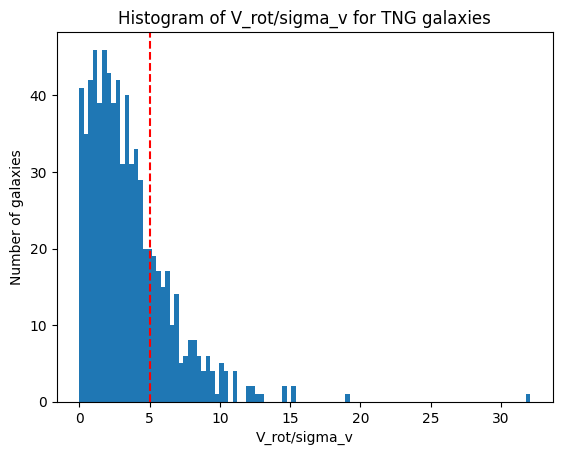

stellar mass cut 754
Stellar ratio cut 270
Gas ratio cut 246
R half cut 244
vrot/sigma_v cut 133
alignment mask cut 130
Number of galaxies after cuts is: 130
Number of gals within 200Kpc is 8
Final number of chosen galaxies in TNG is: 122


In [3]:
# TNG Selection criteria 

#Ratio, gas ratio, stellar mass, r_half limit, alignment, minimum distnace, v_rot/sigma_v

RAR.TNG_cuts(Chosen_galaxies_TNG, galaxy_dataframe_TNG, 0.3, 0.25, 10**7, 200, 0.95, 200, 5)

#Max Radius for r/r_half_gas 

max_radius_TNG = 2 

min_radius_TNG = 0.1



## NewHorizon

stellar mass cut 427
Stellar ratio cut 177
Gas ratio cut 161
R half cut 161
alignment mask cut 157
vrot/sigma_v cut 80
Number of galaxies after cuts is: 80
Final number of chosen galaxies in NH is: 76


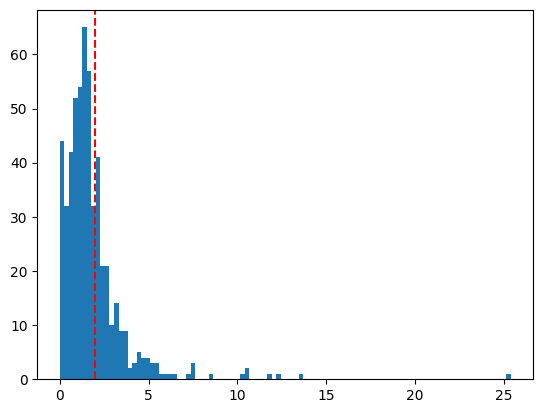

In [4]:
# NH Selection criteria 

# Ratio, gas ratio, stellar mass, r_half_max, alignment, v_rot/sigma_v

RAR.NH_cuts(Chosen_galaxies_NH, galaxy_dataframe_NH, 0.3, 0.25, 10**7, 200, 0.95, 2)

#Max Radius for r/r_half_gas 

max_radius_NH = 2

min_radius_NH = 0.1



# Loading Pytreegrav Results

In [5]:
#PYTREEGRAV RESULTS TNG


Chosen_galaxies_NH = np.loadtxt('/mnt/users/darnej/MPhys/Chosen_galaxies_final_NH.txt')

Chosen_galaxies_TNG = np.loadtxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_final_TNG.txt')


pytree_results_TNG, pytree_results_NH = RAR.get_pytree_TNG_NH(Chosen_galaxies_TNG, Chosen_galaxies_NH)



# 1. Pytreegrav RAR — $g_{tot}$ vs $g_{bar}$

## TNG-50

1320
1320
1320
1320


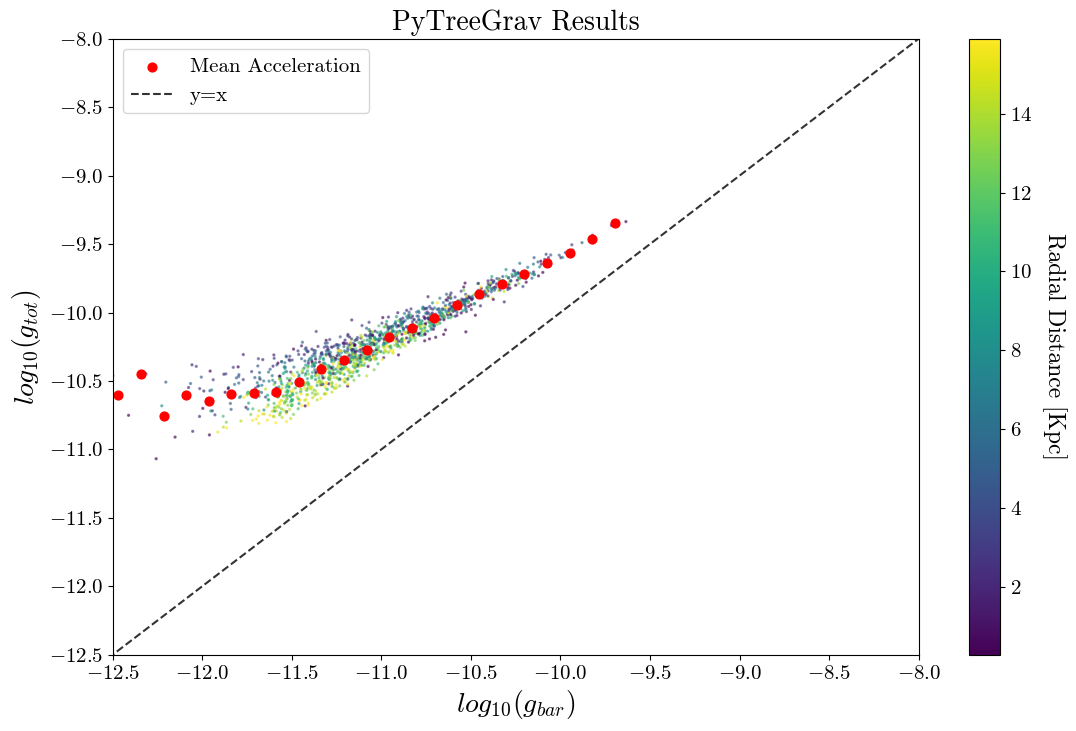

In [6]:
#PLOTTING TNG PYTREEGRAV RESULTS


g_bar_all_tree, g_tot_all_tree, bincenters_TNG_tree, mean_TNG_tree = RAR.Plot_pytree(pytree_results_TNG, gas_r_half_TNG, gal_indices_TNG, min_radius_TNG, max_radius_TNG)


sample: 100%|██████████| 2500/2500 [00:17<00:00, 140.51it/s, 155 steps of size 1.59e-02. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -4.06      0.07     -4.06     -4.17     -3.93    546.56      1.00
         k      0.56      0.01      0.56      0.55      0.57    546.09      1.00
     sigma      0.11      0.00      0.11      0.11      0.11    837.38      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


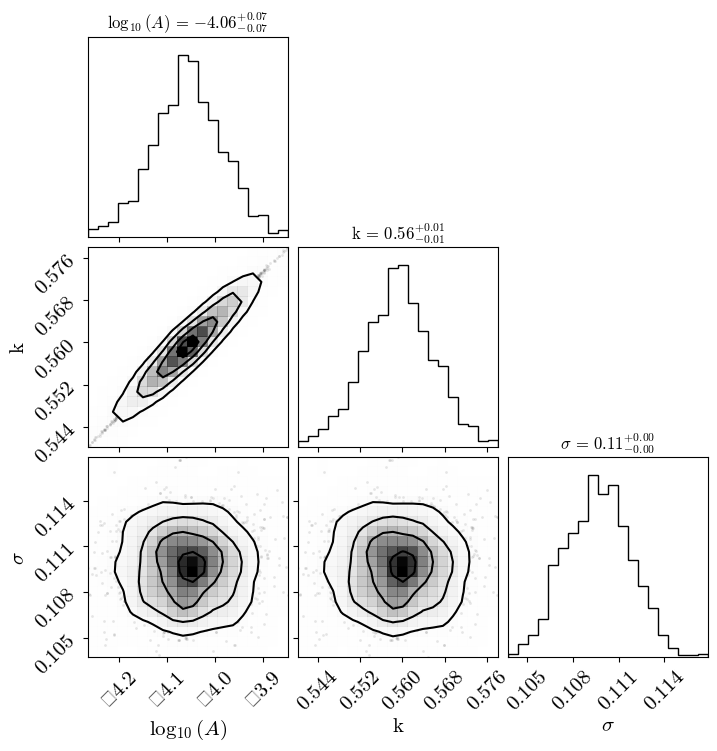

sample: 100%|██████████| 2500/2500 [00:04<00:00, 606.72it/s, 3 steps of size 1.05e+00. acc. prob=0.89]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      3.12      0.05      3.12      3.04      3.19   2216.80      1.00
     sigma      0.11      0.00      0.11      0.10      0.11   1998.21      1.00

Number of divergences: 0


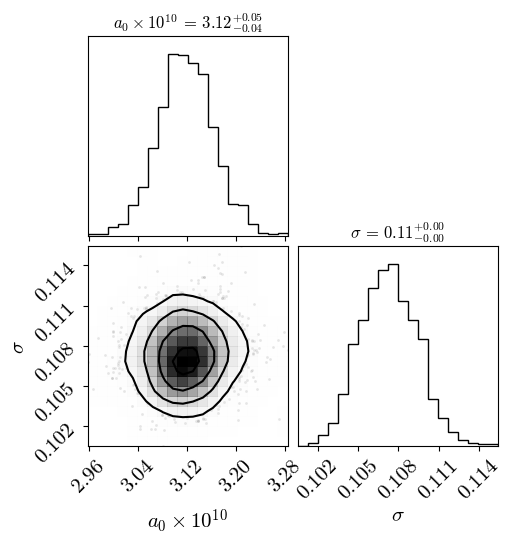

sample: 100%|██████████| 2500/2500 [00:18<00:00, 137.29it/s, 15 steps of size 1.75e-01. acc. prob=0.96]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      2.61      0.15      2.60      2.37      2.85    788.38      1.01
     shape      0.77      0.05      0.77      0.70      0.85    768.87      1.01
     sigma      0.11      0.00      0.11      0.10      0.11    921.06      1.00

Number of divergences: 0


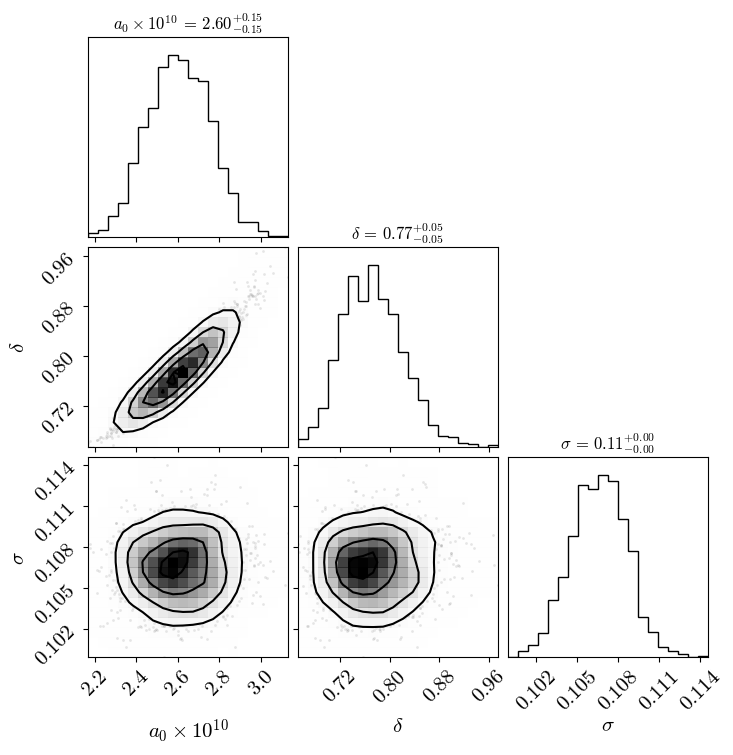

In [7]:
gbar, gtot = g_bar_all_tree, g_tot_all_tree

# Power law: g_tot = A * g_bar^k
Samples_TNG_pytree_pl = RAR.Power_law_MCMC(gbar, gtot)

# Simple interpolating function (delta=1)
Samples_TNG_pytree_RAR = RAR.RAR_func_MCMC(gbar, gtot)

# Interpolating function with free shape parameter (delta)
Samples_TNG_pytree_RAR_shape = RAR.RAR_func_shape_MCMC(gbar, gtot)

A: -4.0571012
k: 0.5592343
sigma: 0.10964457


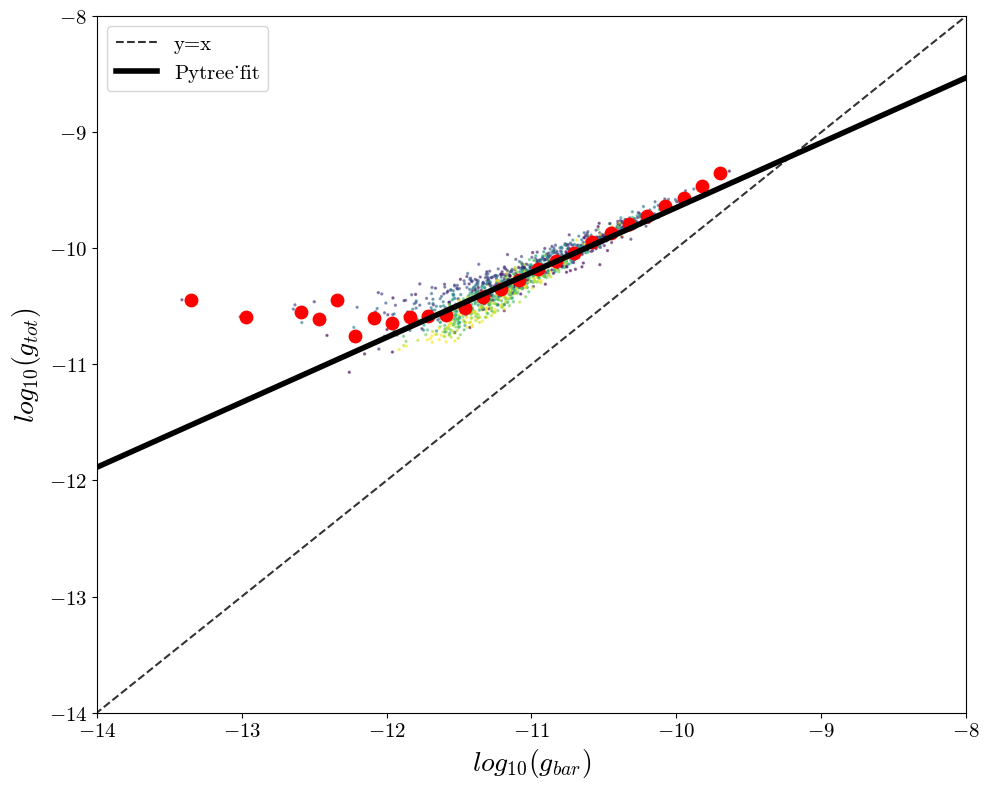

a0: 3.117497
sigma: 0.1072443


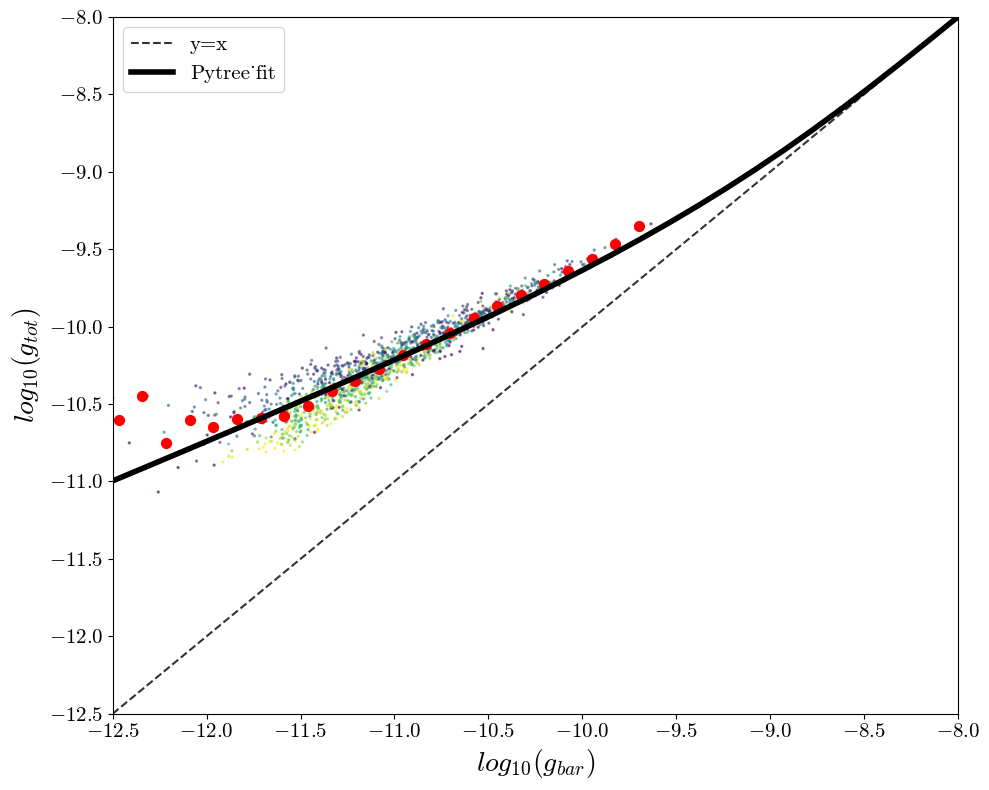

a0: 2.6045275
sigma: 0.10664454
shape: 0.7718249


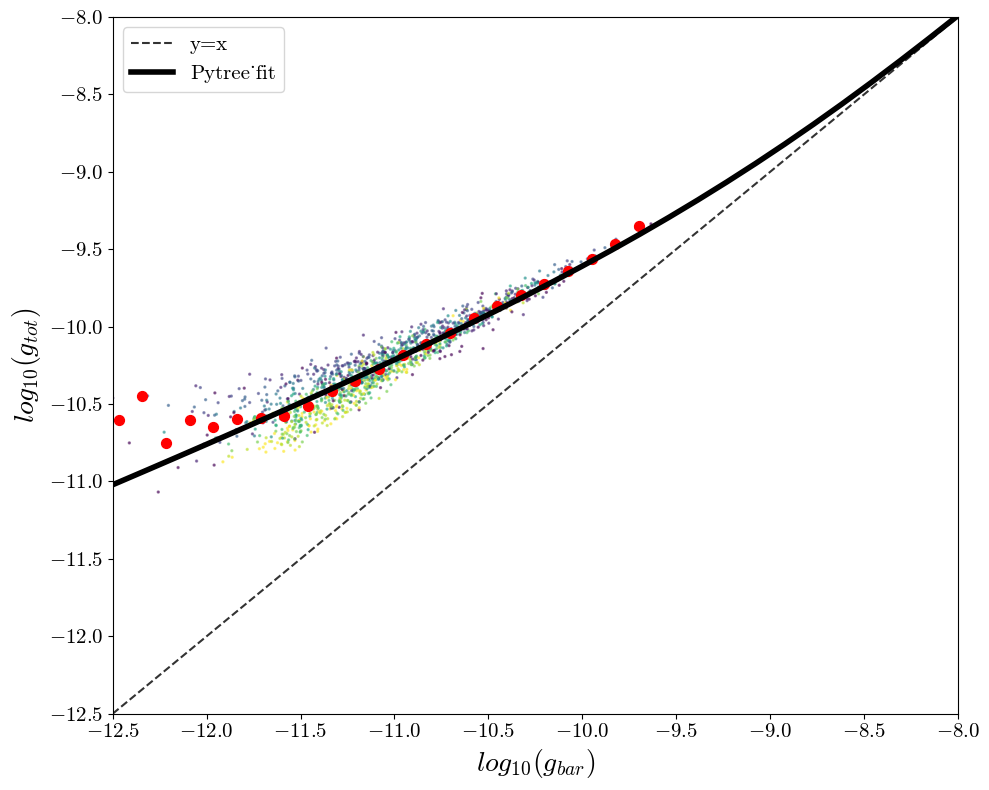

In [8]:
g_tot_pytree_pl_TNG    = RAR.Plot_pytree_power_law(Samples_TNG_pytree_pl,        pytree_results_TNG, gas_r_half_TNG, gal_indices_TNG, min_radius_TNG, max_radius_TNG, bincenters_TNG_tree, mean_TNG_tree)
g_tot_pytree_RAR_TNG   = RAR.Plot_pytree_RAR_func( Samples_TNG_pytree_RAR,       pytree_results_TNG, gas_r_half_TNG, gal_indices_TNG, min_radius_TNG, max_radius_TNG, bincenters_TNG_tree, mean_TNG_tree)
g_tot_pytree_shape_TNG = RAR.Plot_pytree_RAR_shape(Samples_TNG_pytree_RAR_shape, pytree_results_TNG, gas_r_half_TNG, gal_indices_TNG, min_radius_TNG, max_radius_TNG, bincenters_TNG_tree, mean_TNG_tree)

## NewHorizon

817
817
817
817


/mnt/users/darnej/MPhys/Run_gals_final_funcs.py:384: RuntimeWarning: divide by zero encountered in log10
  points = np.array([np.log10(pytree_results_TNG[key][0]), np.log10(pytree_results_TNG[key][1])]).T.reshape(-1, 1, 2)


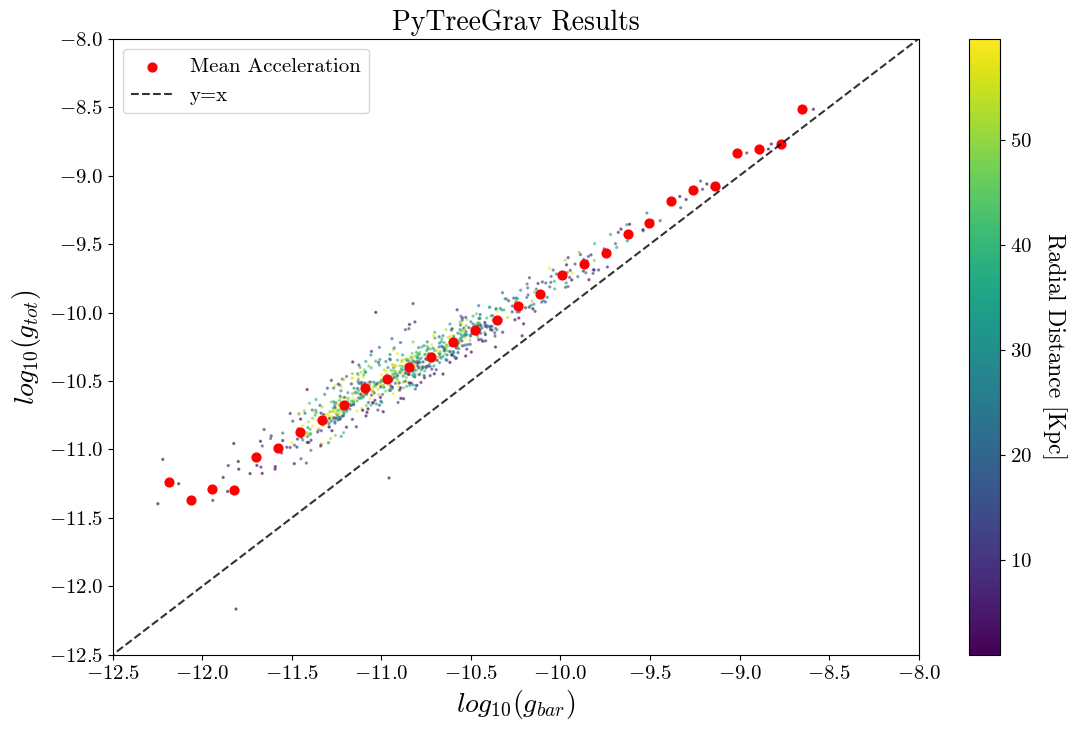

In [9]:
#PLOTTING NH PYTREEGRAV RESULTS

g_bar_all_tree, g_tot_all_tree, bincenters_NH_tree, mean_NH_tree = RAR.Plot_pytree(pytree_results_NH, gas_r_half_NH, gal_indices_NH, min_radius_NH, max_radius_NH)


sample: 100%|██████████| 2500/2500 [00:12<00:00, 204.82it/s, 99 steps of size 1.83e-02. acc. prob=0.95] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -2.03      0.08     -2.03     -2.17     -1.91    514.67      1.00
         k      0.77      0.01      0.77      0.76      0.78    516.97      1.00
     sigma      0.10      0.00      0.10      0.10      0.11    781.85      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


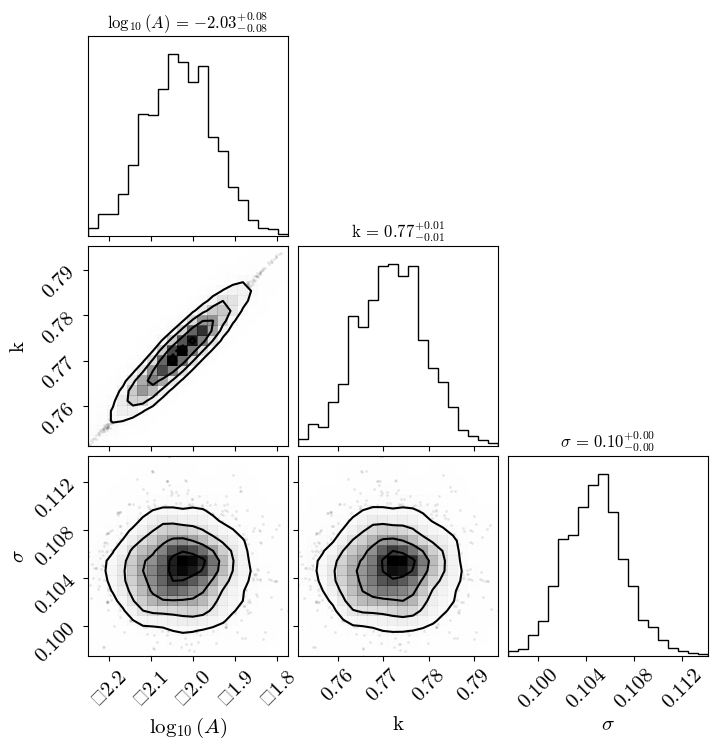

sample: 100%|██████████| 2500/2500 [00:03<00:00, 662.12it/s, 3 steps of size 9.15e-01. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.65      0.02      0.65      0.62      0.67   2030.91      1.00
     sigma      0.12      0.00      0.12      0.12      0.13   1822.42      1.00

Number of divergences: 0


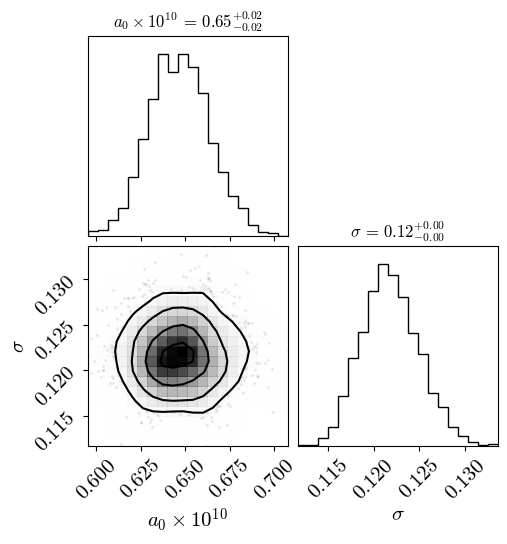

sample: 100%|██████████| 2500/2500 [00:23<00:00, 107.60it/s, 27 steps of size 5.24e-02. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.03      0.01      0.03      0.01      0.05    507.66      1.00
     shape      0.33      0.02      0.33      0.29      0.36    519.48      1.00
     sigma      0.10      0.00      0.10      0.10      0.11    934.18      1.00

Number of divergences: 0


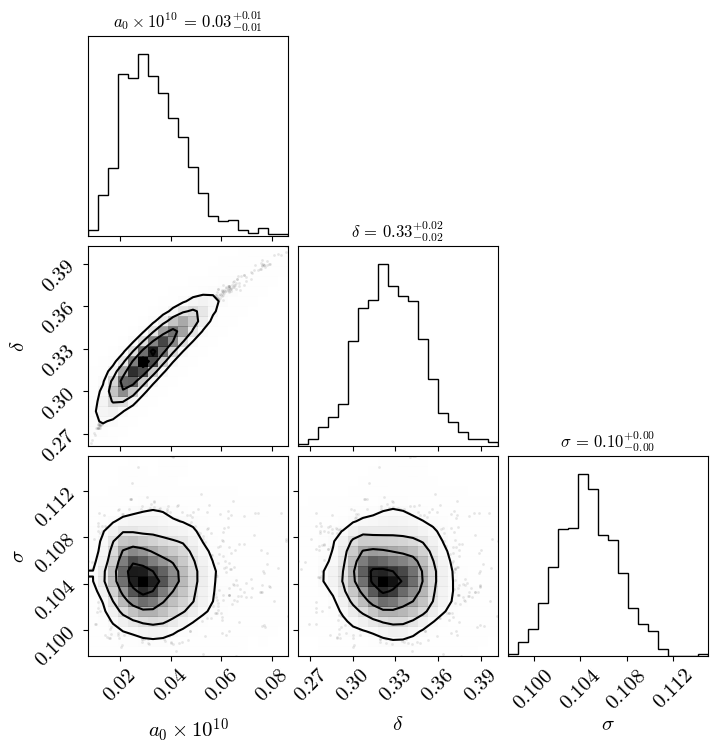

In [10]:
gbar, gtot = g_bar_all_tree, g_tot_all_tree

Samples_NH_pytree_pl        = RAR.Power_law_MCMC(gbar, gtot)
Samples_NH_pytree_RAR       = RAR.RAR_func_MCMC(gbar, gtot)
Samples_NH_pytree_RAR_shape = RAR.RAR_func_shape_MCMC(gbar, gtot)

A: -2.0308812
k: 0.77172905
sigma: 0.10468638


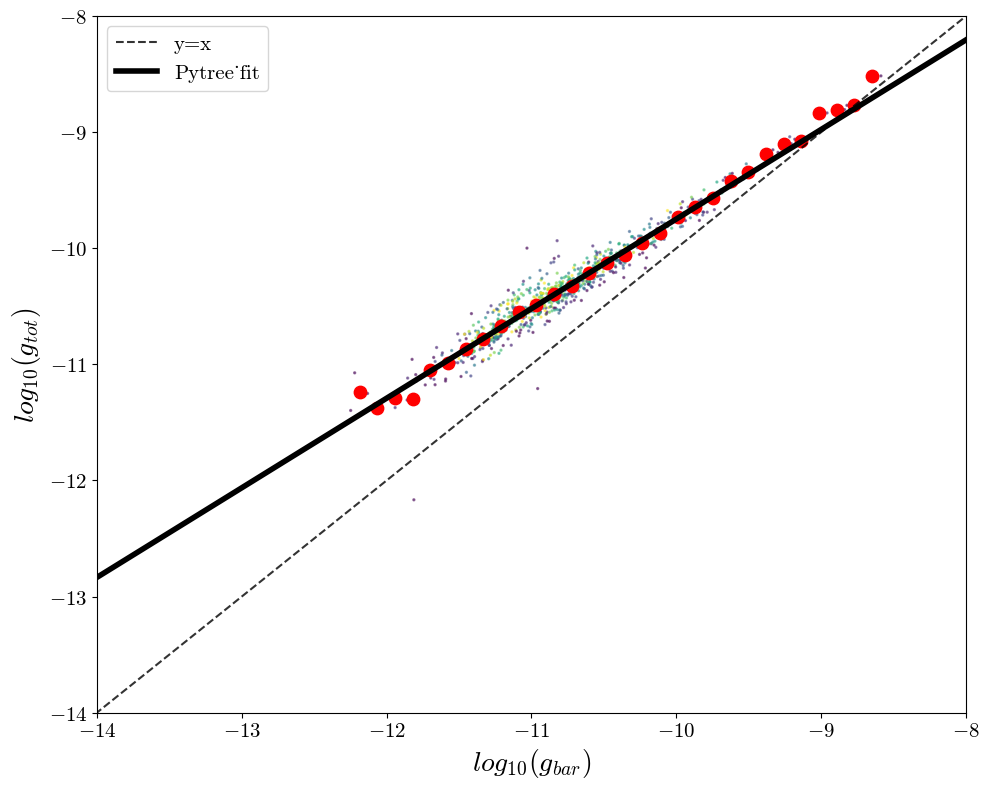

a0: 0.64681447
sigma: 0.12168602


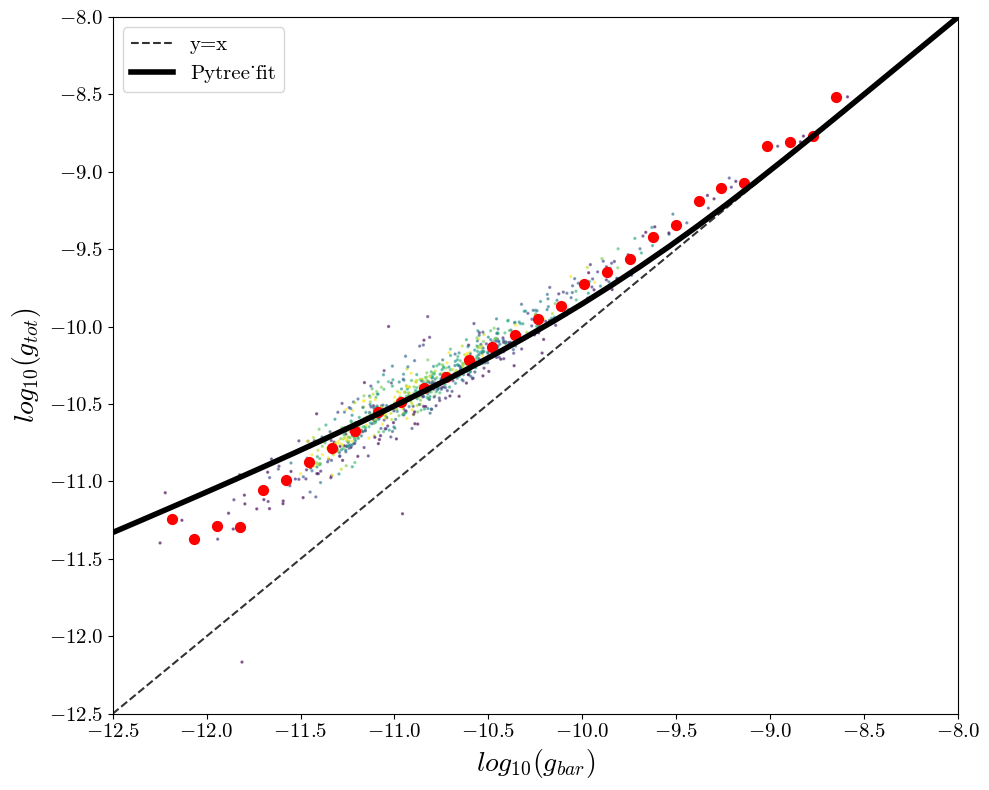

a0: 0.03203962
sigma: 0.10462026
shape: 0.32550466


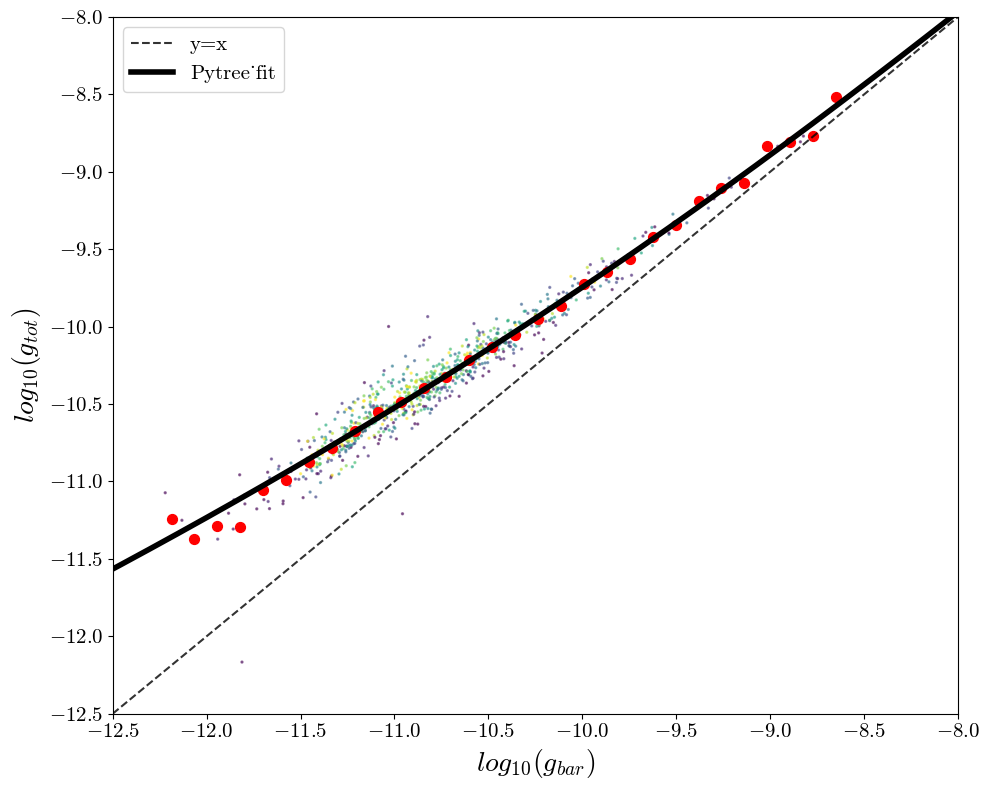

In [11]:
g_tot_pytree_pl_NH    = RAR.Plot_pytree_power_law(Samples_NH_pytree_pl,        pytree_results_NH, gas_r_half_NH, gal_indices_NH, min_radius_NH, max_radius_NH, bincenters_NH_tree, mean_NH_tree)
g_tot_pytree_RAR_NH   = RAR.Plot_pytree_RAR_func( Samples_NH_pytree_RAR,       pytree_results_NH, gas_r_half_NH, gal_indices_NH, min_radius_NH, max_radius_NH, bincenters_NH_tree, mean_NH_tree)
g_tot_pytree_shape_NH = RAR.Plot_pytree_RAR_shape(Samples_NH_pytree_RAR_shape, pytree_results_NH, gas_r_half_NH, gal_indices_NH, min_radius_NH, max_radius_NH, bincenters_NH_tree, mean_NH_tree)

# 2. Spherical RAR — $g_{obs}$ vs $g_{bar}$ and $g_{tot,sph}$ vs $g_{bar}$

## TNG-50

In [12]:
#Plotting RAR for all Galaxies

g_bar_all, g_rot_all, g_tot_all, g_obs_all, bincenters_rot_TNG, mean_rot_TNG, bincenters_tot_TNG, mean_tot_TNG, bincenters_rar_TNG, mean_rar_TNG, rar_TNG = RAR.get_RAR_data(Chosen_galaxies_TNG, gas_r_half_TNG, gal_indices_TNG, min_radius_TNG, max_radius_TNG, sim = 'TNG')

1280
1280
1280
1280


122


/mnt/users/darnej/MPhys/Run_gals_final_funcs.py:976: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


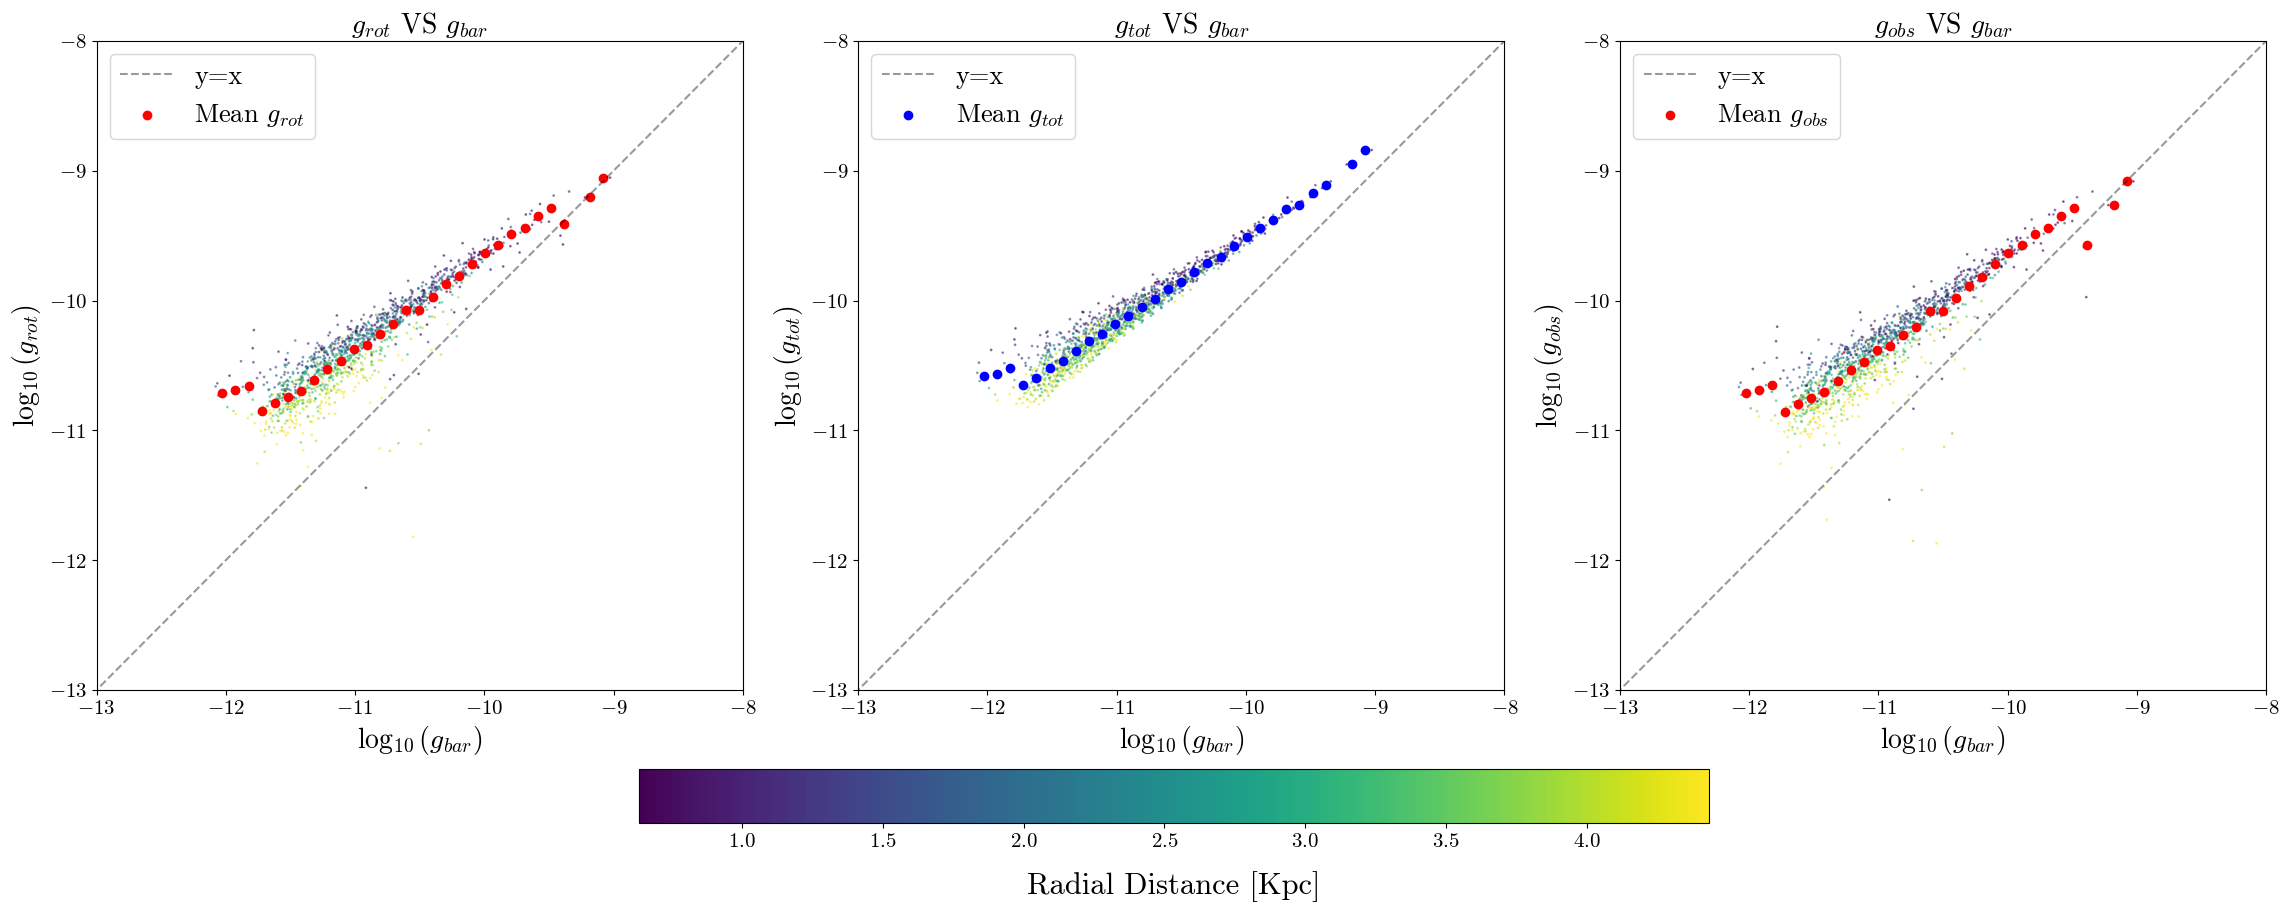

In [13]:
print(len(rar_TNG))

RAR.Plot_RARs(rar_TNG, bincenters_rot_TNG, mean_rot_TNG, bincenters_tot_TNG, mean_tot_TNG, bincenters_rar_TNG, mean_rar_TNG)

sample: 100%|██████████| 2500/2500 [00:15<00:00, 163.26it/s, 127 steps of size 1.64e-02. acc. prob=0.96]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -2.84      0.11     -2.84     -3.02     -2.66    726.50      1.00
         k      0.69      0.01      0.69      0.67      0.70    724.84      1.00
     sigma      0.18      0.00      0.18      0.17      0.18    755.07      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


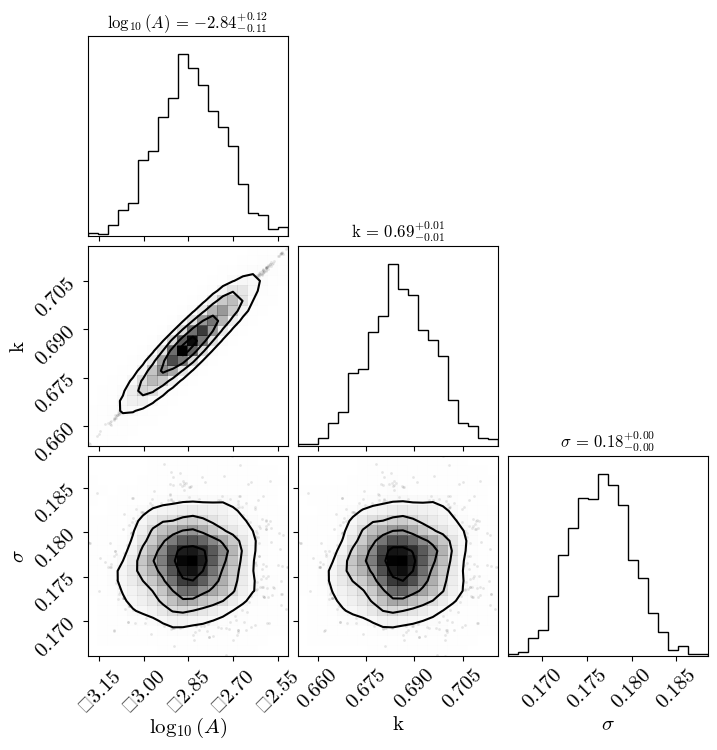

sample: 100%|██████████| 2500/2500 [00:03<00:00, 644.34it/s, 3 steps of size 1.00e+00. acc. prob=0.89]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      1.23      0.03      1.23      1.17      1.28   2125.38      1.00
     sigma      0.18      0.00      0.18      0.18      0.19   1935.68      1.00

Number of divergences: 0


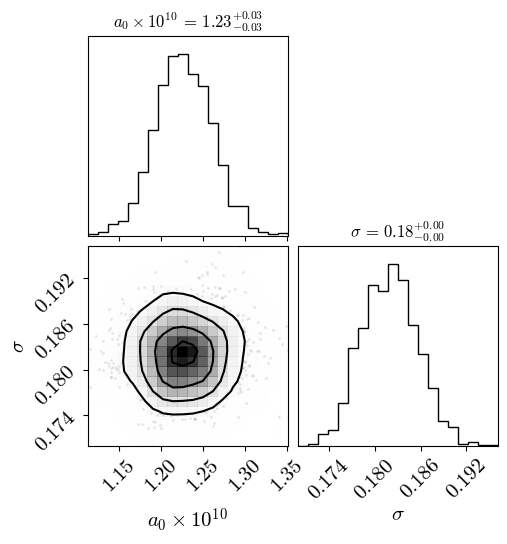

sample: 100%|██████████| 2500/2500 [00:22<00:00, 111.83it/s, 19 steps of size 9.45e-02. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.35      0.08      0.34      0.23      0.50    522.69      1.00
     shape      0.46      0.04      0.46      0.40      0.52    516.59      1.00
     sigma      0.18      0.00      0.18      0.17      0.18    955.97      1.00

Number of divergences: 0


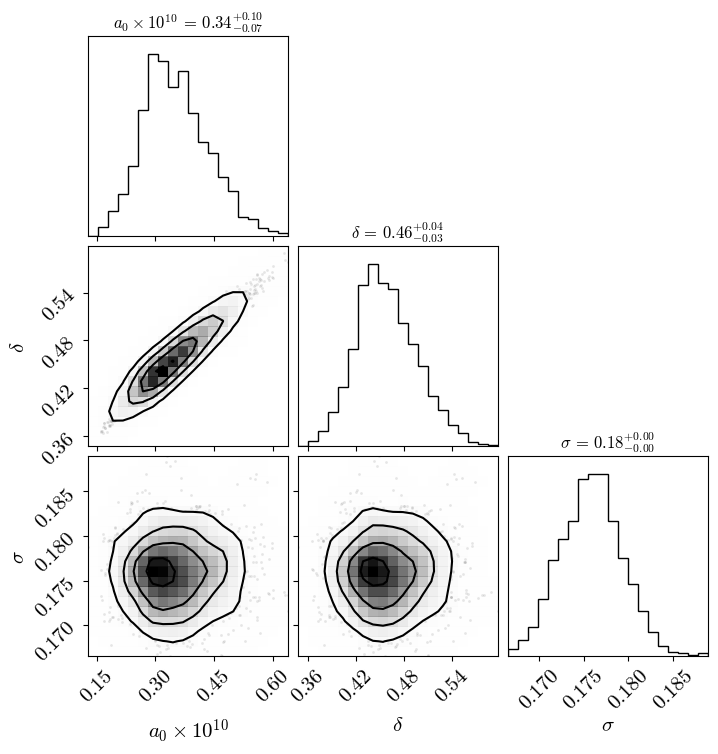

In [14]:
# RAR_sph: g_obs vs g_bar
gbar, gobs = g_bar_all, g_obs_all

Samples_TNG_RAR_pl        = RAR.Power_law_MCMC(gbar, gobs)
Samples_TNG_RAR_RAR       = RAR.RAR_func_MCMC(gbar, gobs)
Samples_TNG_RAR_RAR_shape = RAR.RAR_func_shape_MCMC(gbar, gobs)

A: -2.8441818
k 0.6856668
sigma: 0.17657682


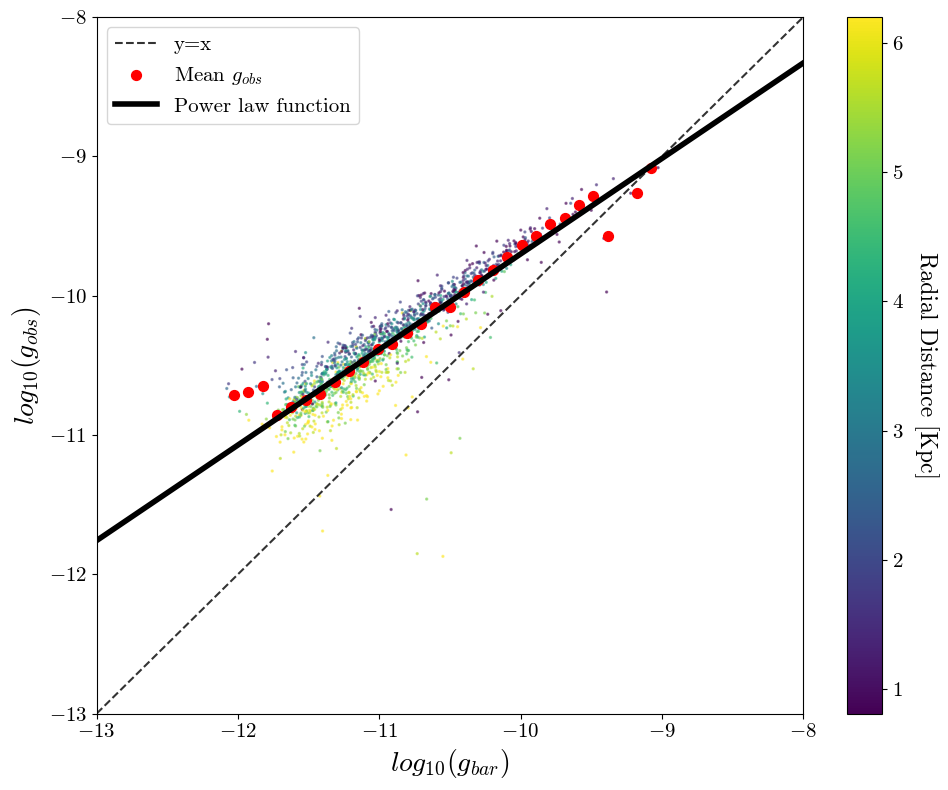

a0: 1.2263579
shape: 1
sigma: 0.1820074


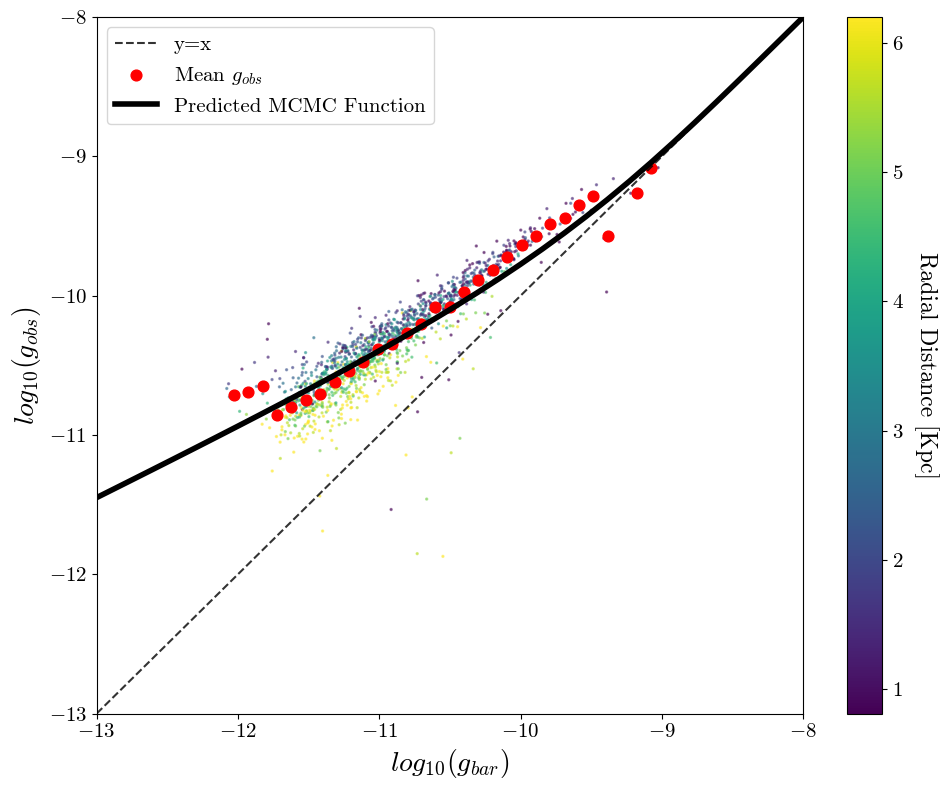

a0: 0.34355128
shape: 0.4554481
sigma: 0.17587641


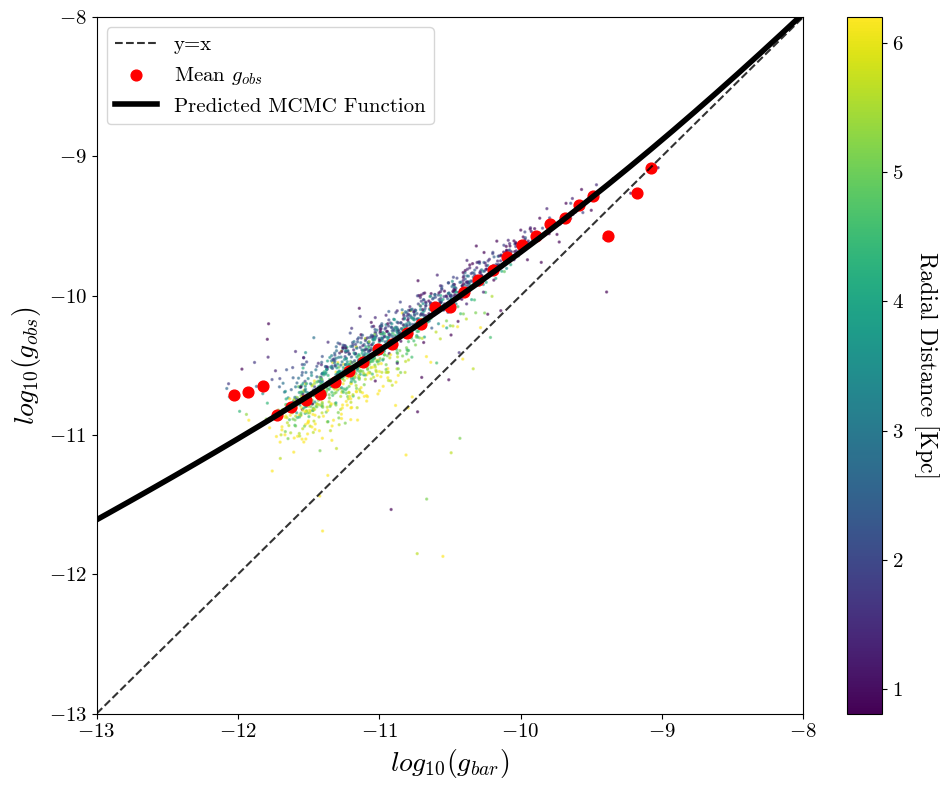

In [15]:
g_obs_RAR_pl_TNG    = RAR.Plot_RAR_power_law( Samples_TNG_RAR_pl,        rar_TNG, bincenters_rar_TNG, mean_rar_TNG)
g_obs_RAR_RAR_TNG   = RAR.Plot_RAR_RAR_func(  Samples_TNG_RAR_RAR,       rar_TNG, bincenters_rar_TNG, mean_rar_TNG)
g_obs_RAR_shape_TNG = RAR.Plot_RAR_RAR_shape( Samples_TNG_RAR_RAR_shape, rar_TNG, bincenters_rar_TNG, mean_rar_TNG)

sample: 100%|██████████| 2500/2500 [00:14<00:00, 171.15it/s, 215 steps of size 3.74e-03. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -3.00      0.05     -3.00     -3.09     -2.91    625.80      1.00
         k      0.65      0.01      0.65      0.64      0.66    631.18      1.00
     sigma      0.09      0.00      0.09      0.08      0.09    586.28      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


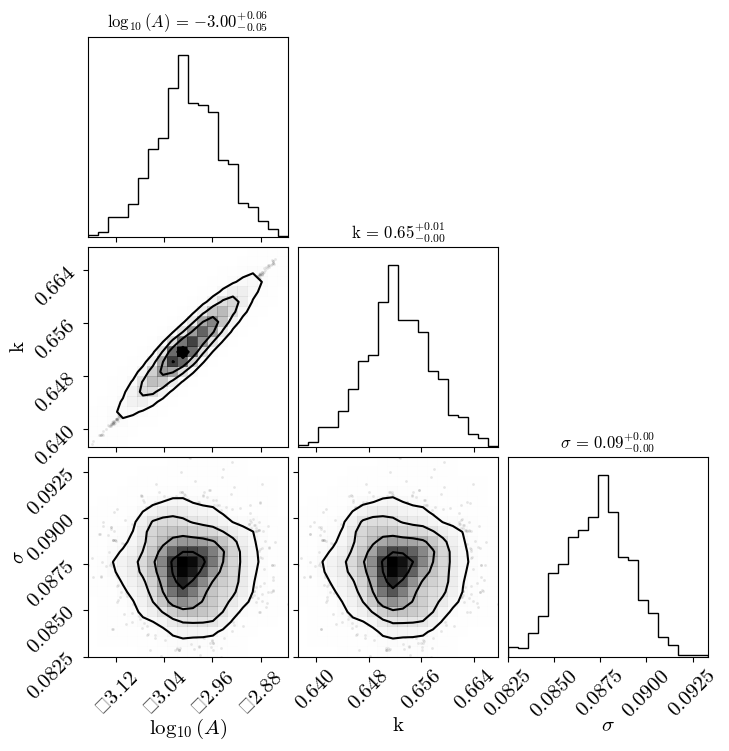

sample: 100%|██████████| 2500/2500 [00:03<00:00, 668.20it/s, 3 steps of size 1.03e+00. acc. prob=0.89]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      3.71      0.05      3.71      3.63      3.80   2117.21      1.00
     sigma      0.10      0.00      0.10      0.10      0.10   1816.93      1.00

Number of divergences: 0


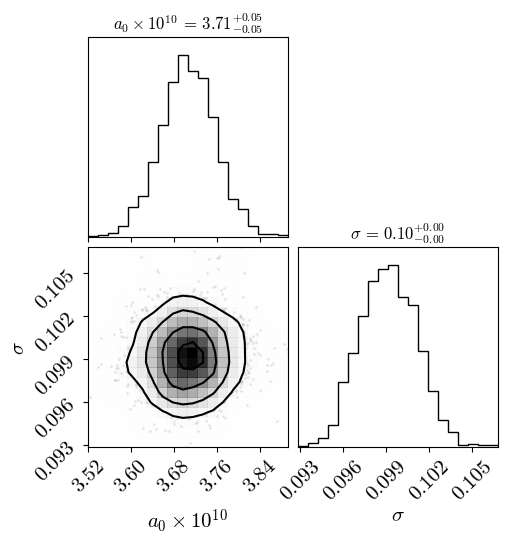

sample: 100%|██████████| 2500/2500 [00:23<00:00, 107.96it/s, 31 steps of size 9.39e-02. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      1.06      0.12      1.06      0.88      1.28    657.63      1.00
     shape      0.42      0.02      0.41      0.39      0.44    649.04      1.00
     sigma      0.09      0.00      0.09      0.08      0.09    855.20      1.00

Number of divergences: 0


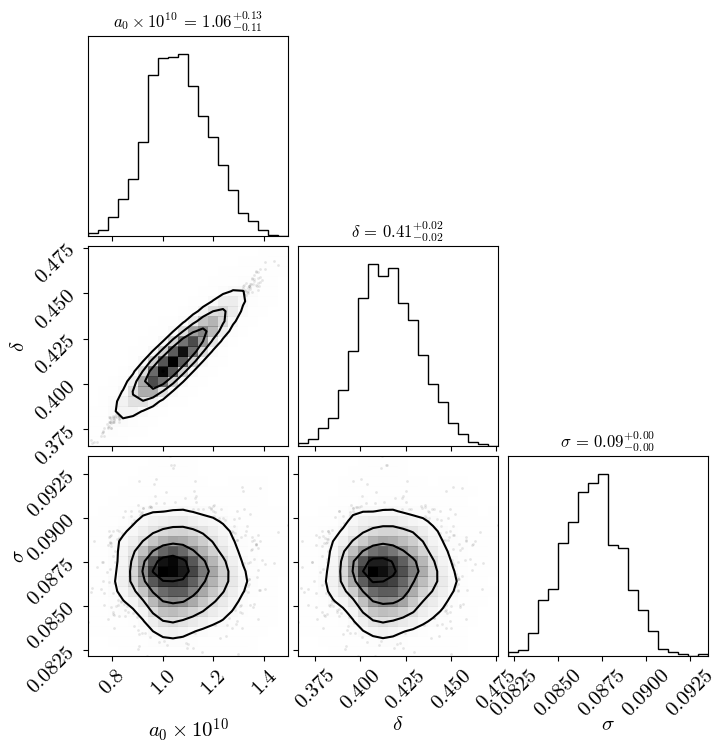

In [16]:
# g_tot_sph vs g_bar
gbar, gtot = g_bar_all, g_tot_all

Samples_TNG_tot_pl        = RAR.Power_law_MCMC(gbar, gtot)
Samples_TNG_tot_RAR       = RAR.RAR_func_MCMC(gbar, gtot)
Samples_TNG_tot_RAR_shape = RAR.RAR_func_shape_MCMC(gbar, gtot)

A: -3.002451
k: 0.65223634
sigma: 0.08739477


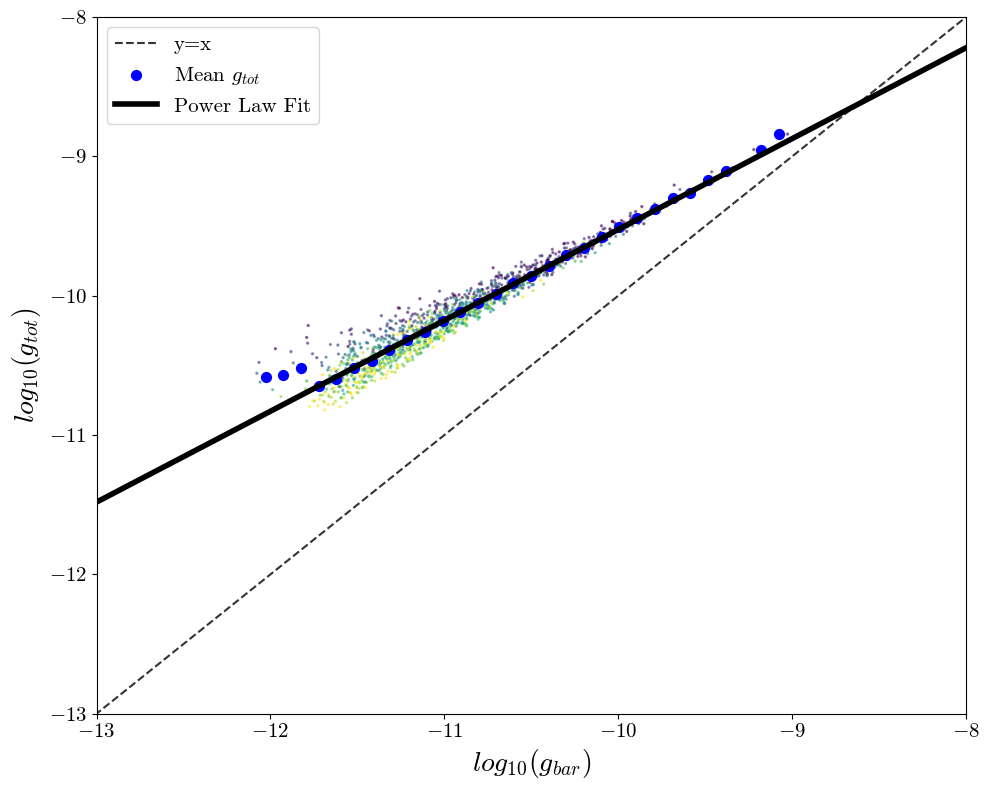

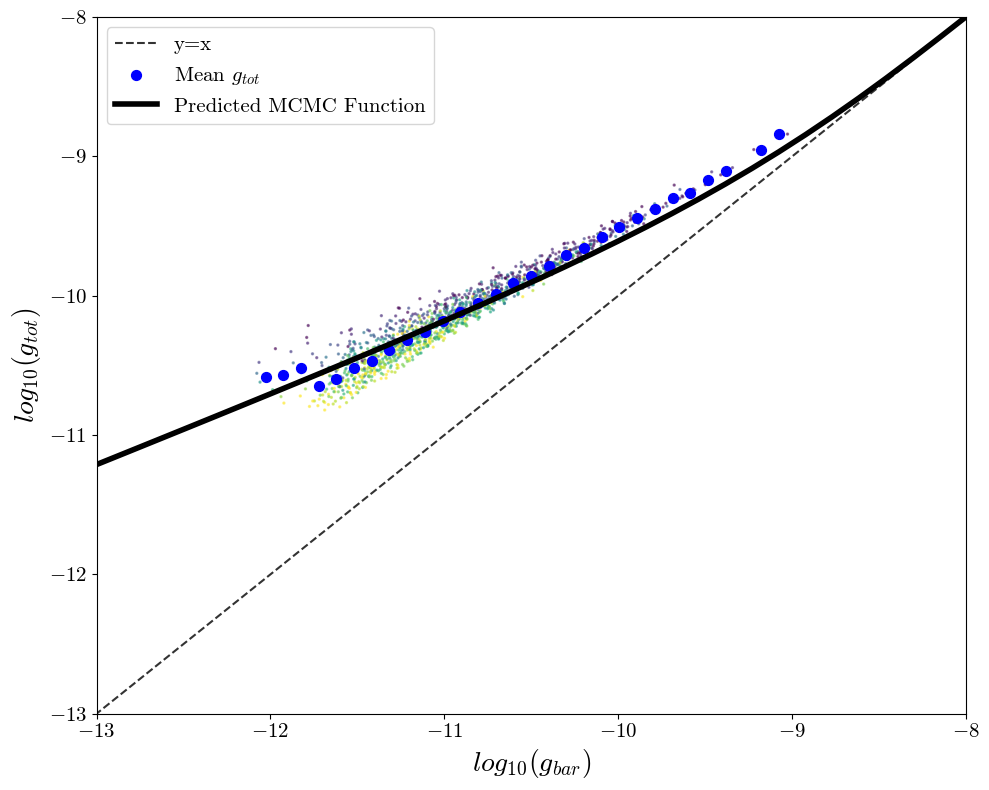

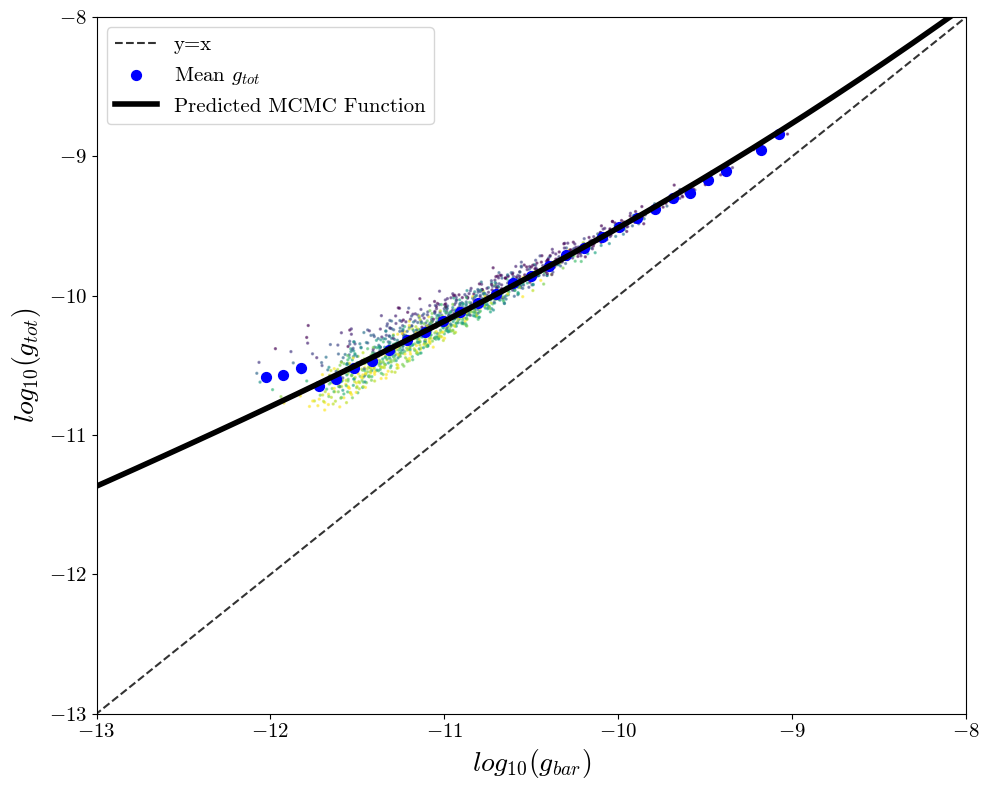

In [17]:
g_tot_RAR_pl_TNG    = RAR.Plot_tot_power_law(Samples_TNG_tot_pl,        rar_TNG, bincenters_tot_TNG, mean_tot_TNG)
g_tot_RAR_RAR_TNG   = RAR.Plot_tot_RAR_func( Samples_TNG_tot_RAR,       rar_TNG, bincenters_tot_TNG, mean_tot_TNG)
g_tot_RAR_shape_TNG = RAR.Plot_tot_RAR_shape(Samples_TNG_tot_RAR_shape, rar_TNG, bincenters_tot_TNG, mean_tot_TNG)

## NewHorizon

In [18]:


g_bar_all, g_rot_all, g_tot_all, g_obs_all, bincenters_rot_NH, mean_rot_NH, bincenters_tot_NH, mean_tot_NH, bincenters_rar_NH, mean_rar_NH, rar_NH = RAR.get_RAR_data(Chosen_galaxies_NH, gas_r_half_NH, gal_indices_NH, min_radius_NH, max_radius_NH, sim = 'NH')


836
836
836
836


76


/mnt/users/darnej/MPhys/Run_gals_final_funcs.py:976: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


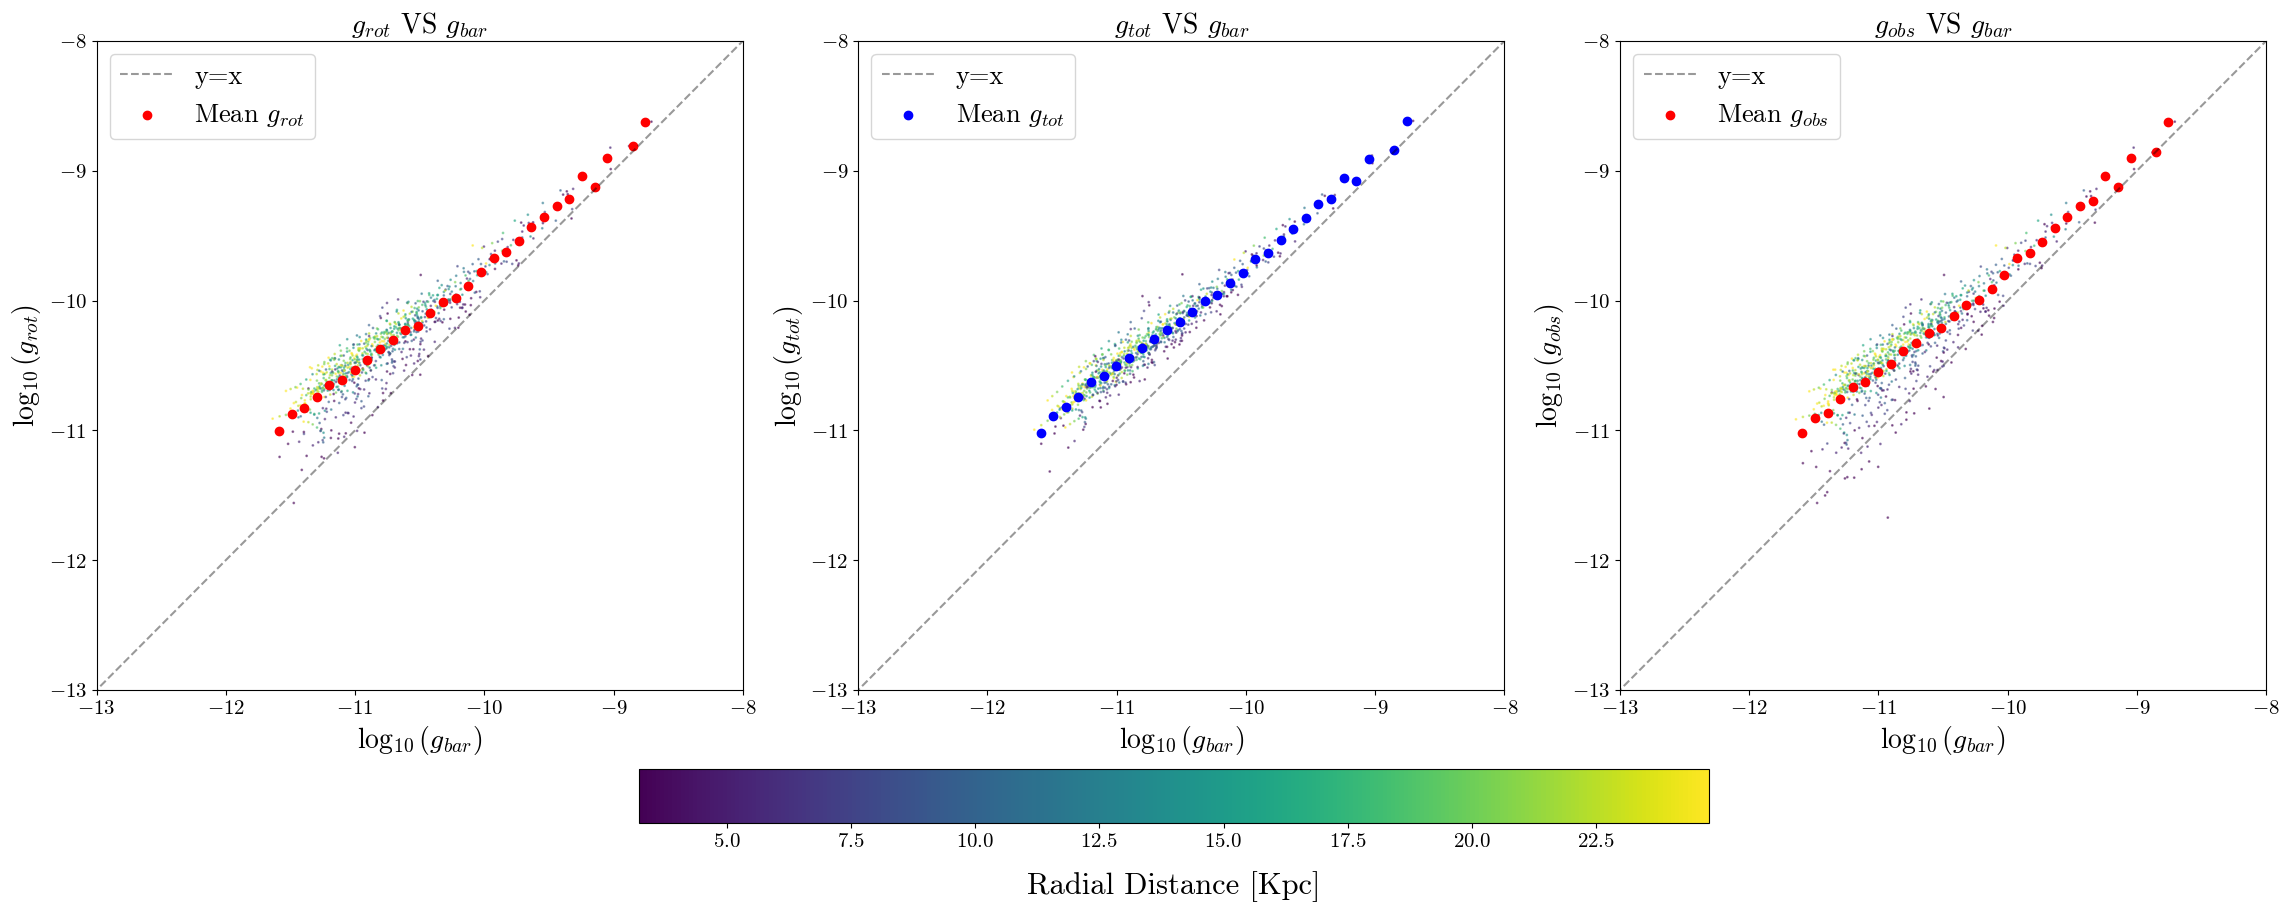

In [19]:
print(len(rar_NH))

RAR.Plot_RARs(rar_NH, bincenters_rot_NH, mean_rot_NH, bincenters_tot_NH, mean_tot_NH, bincenters_rar_NH, mean_rar_NH)


sample: 100%|██████████| 2500/2500 [00:10<00:00, 228.86it/s, 143 steps of size 2.40e-02. acc. prob=0.96]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -2.07      0.14     -2.07     -2.32     -1.86    509.97      1.00
         k      0.77      0.01      0.77      0.75      0.79    509.28      1.00
     sigma      0.18      0.00      0.18      0.17      0.18    840.33      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


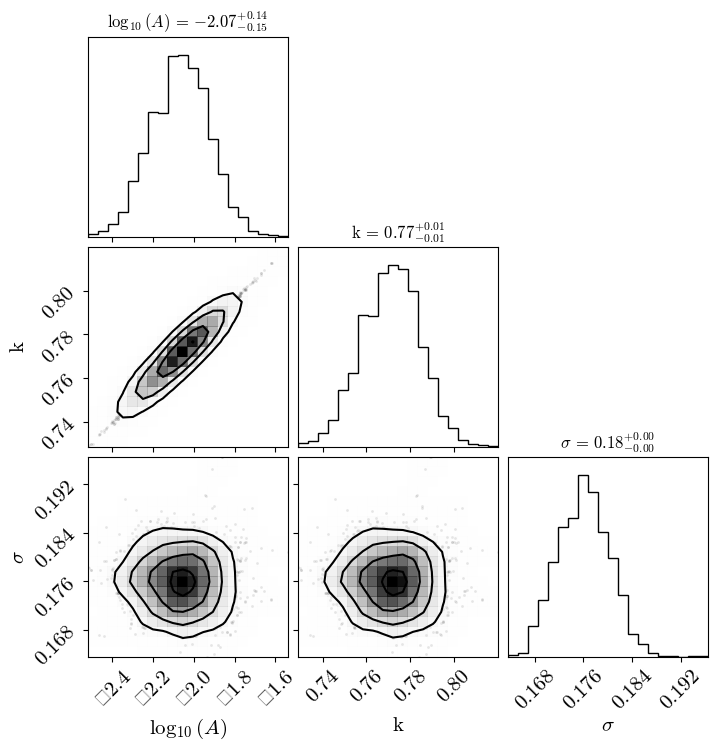

sample: 100%|██████████| 2500/2500 [00:03<00:00, 685.79it/s, 3 steps of size 9.89e-01. acc. prob=0.91] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.57      0.02      0.57      0.54      0.61   2135.79      1.00
     sigma      0.18      0.00      0.18      0.17      0.19   1496.63      1.00

Number of divergences: 0


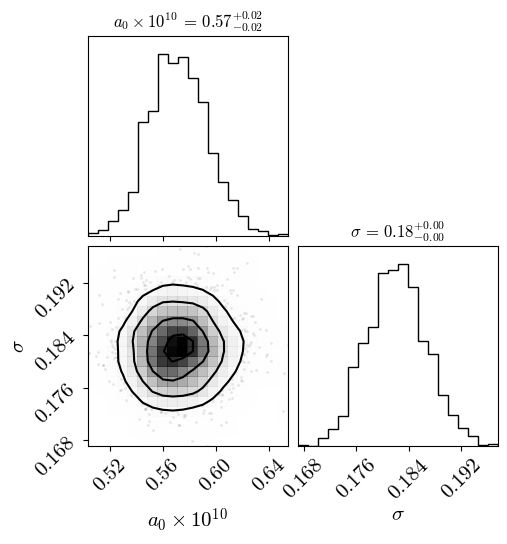

sample: 100%|██████████| 2500/2500 [00:21<00:00, 114.41it/s, 27 steps of size 6.67e-02. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.08      0.04      0.07      0.02      0.13    702.91      1.00
     shape      0.40      0.05      0.40      0.33      0.48    693.63      1.00
     sigma      0.18      0.00      0.17      0.17      0.18    835.57      1.00

Number of divergences: 0


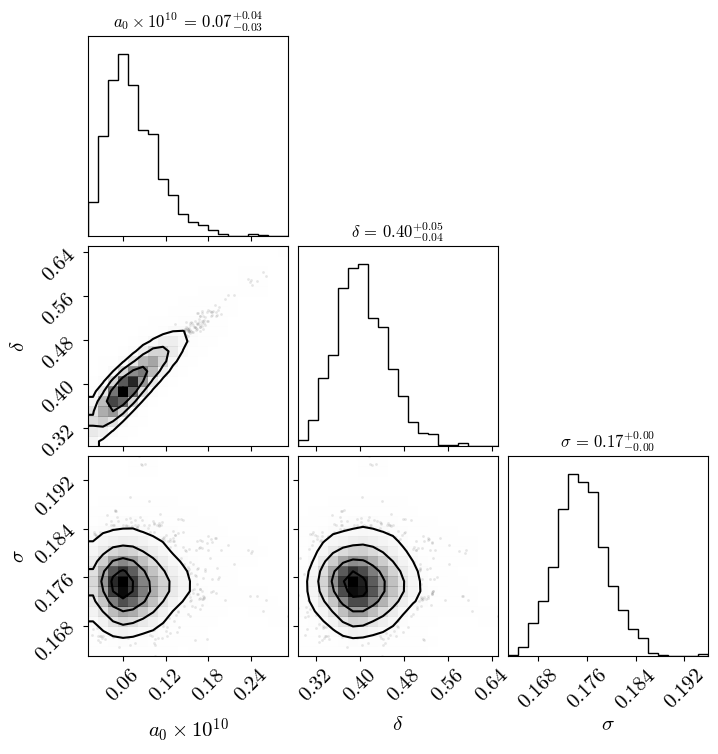

In [20]:
# RAR_sph: g_obs vs g_bar
gbar, gobs = g_bar_all, g_obs_all

Samples_NH_RAR_pl        = RAR.Power_law_MCMC(gbar, gobs)
Samples_NH_RAR_RAR       = RAR.RAR_func_MCMC(gbar, gobs)
Samples_NH_RAR_RAR_shape = RAR.RAR_func_shape_MCMC(gbar, gobs)

A: -2.0655713
k 0.7712129
sigma: 0.17613284


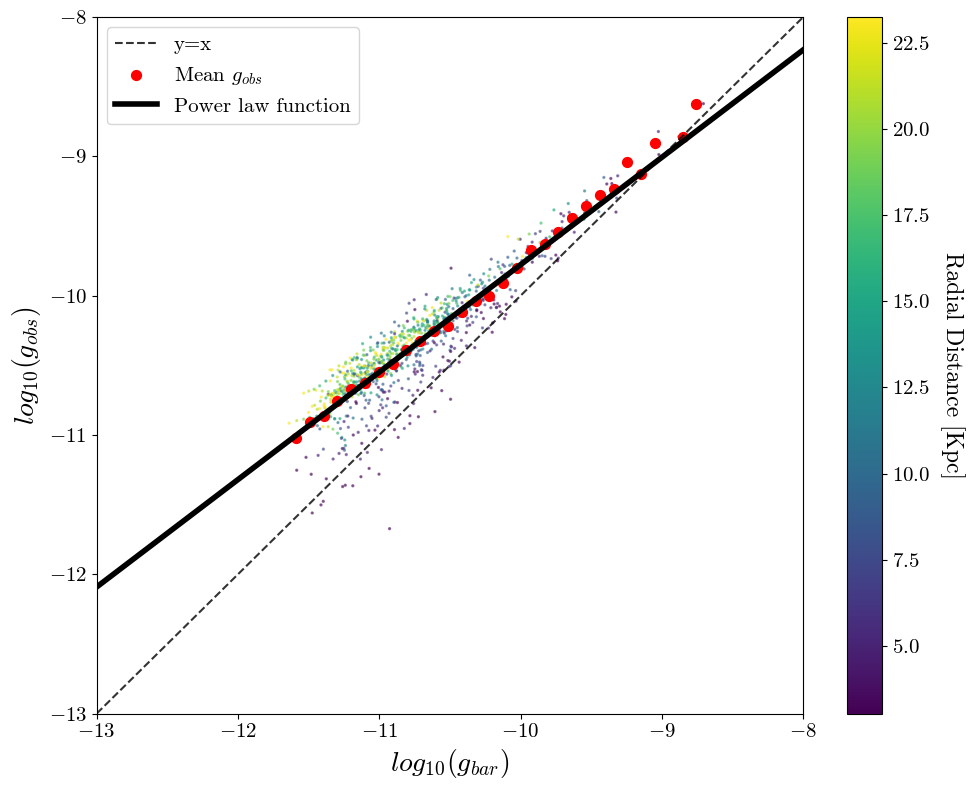

a0: 0.5712047
shape: 1
sigma: 0.18204817


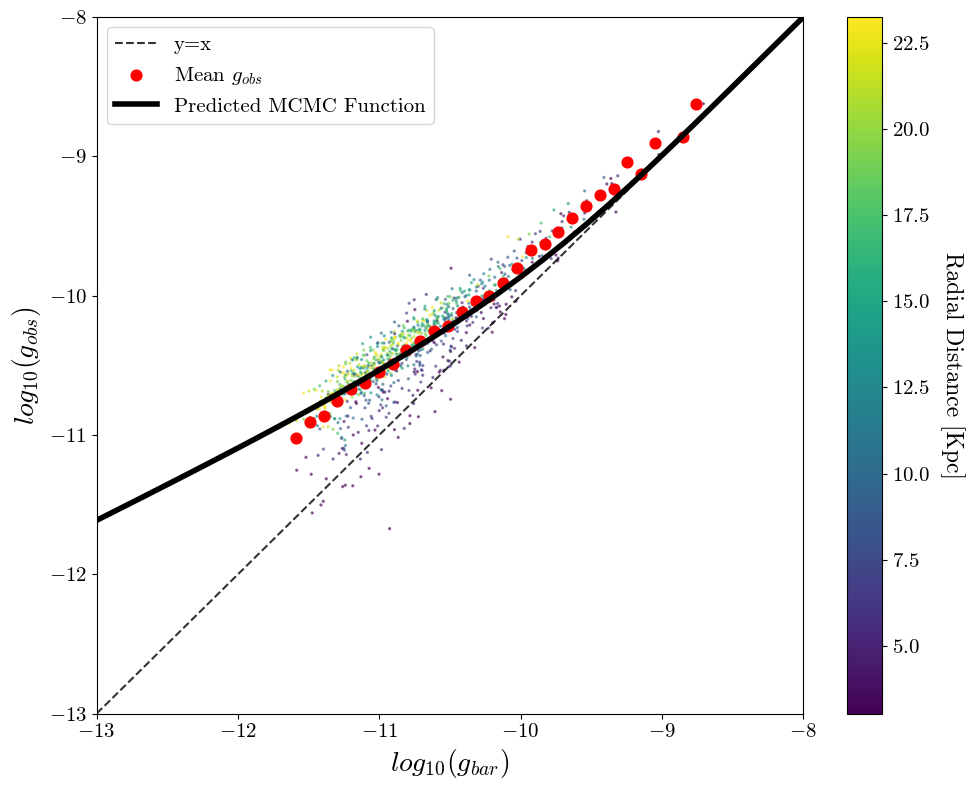

a0: 0.06889784
shape: 0.40068287
sigma: 0.17495145


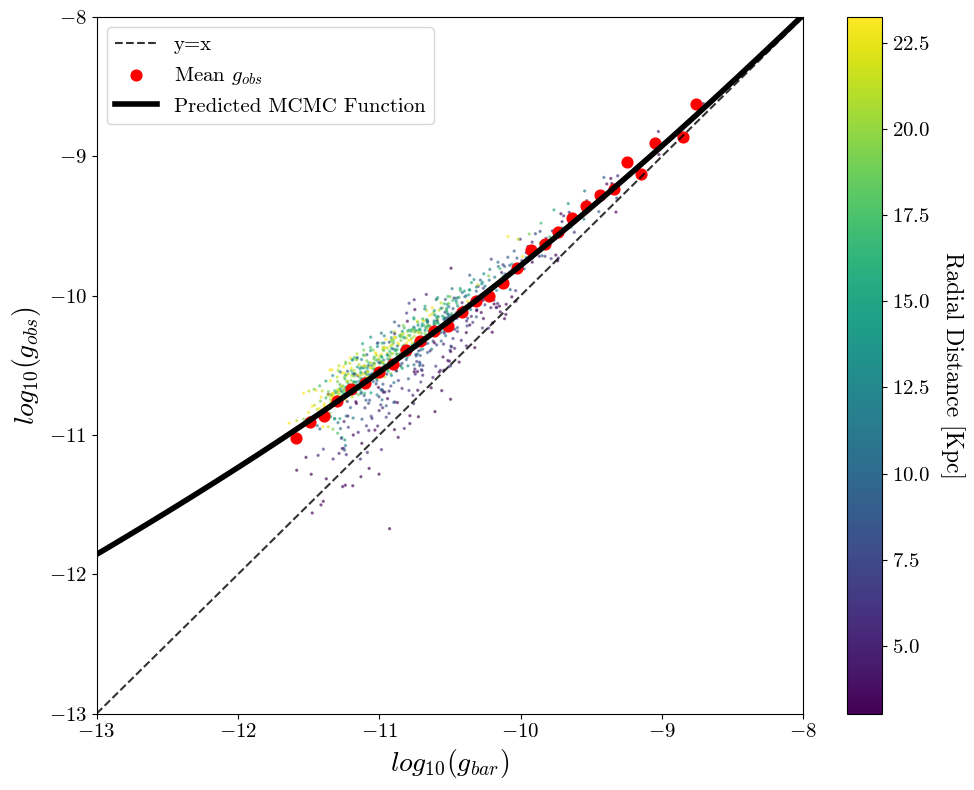

In [21]:
g_obs_RAR_pl_NH    = RAR.Plot_RAR_power_law( Samples_NH_RAR_pl,        rar_NH, bincenters_rar_NH, mean_rar_NH)
g_obs_RAR_RAR_NH   = RAR.Plot_RAR_RAR_func(  Samples_NH_RAR_RAR,       rar_NH, bincenters_rar_NH, mean_rar_NH)
g_obs_RAR_shape_NH = RAR.Plot_RAR_RAR_shape( Samples_NH_RAR_RAR_shape, rar_NH, bincenters_rar_NH, mean_rar_NH)

sample: 100%|██████████| 2500/2500 [00:12<00:00, 204.12it/s, 83 steps of size 1.78e-02. acc. prob=0.95] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -2.15      0.08     -2.16     -2.27     -2.01    726.65      1.00
         k      0.76      0.01      0.76      0.75      0.77    730.08      1.00
     sigma      0.10      0.00      0.10      0.09      0.10    649.40      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


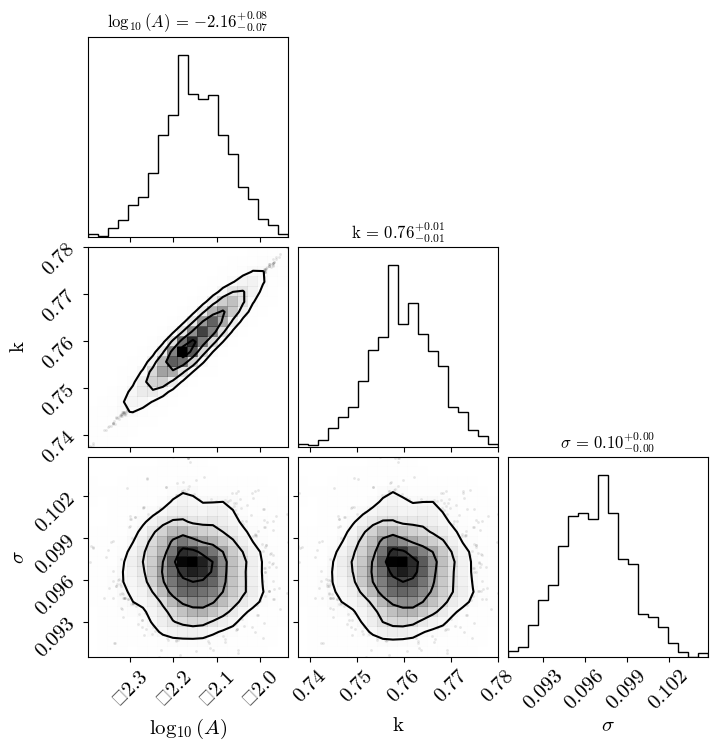

sample: 100%|██████████| 2500/2500 [00:03<00:00, 729.90it/s, 3 steps of size 1.02e+00. acc. prob=0.90] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.71      0.02      0.71      0.69      0.74   1768.00      1.00
     sigma      0.11      0.00      0.11      0.10      0.11   1757.51      1.00

Number of divergences: 0


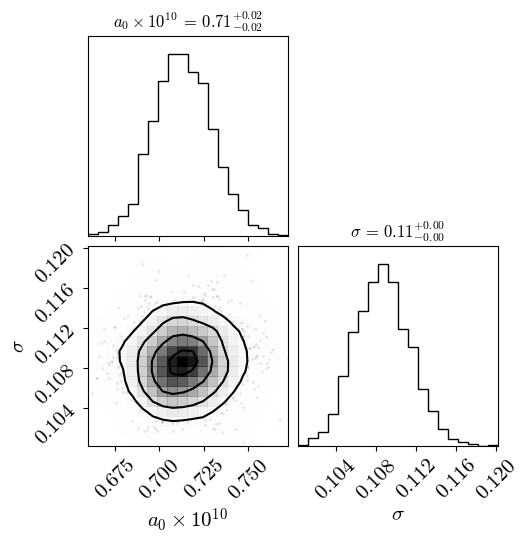

sample: 100%|██████████| 2500/2500 [00:20<00:00, 122.81it/s, 27 steps of size 7.46e-02. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.08      0.02      0.07      0.04      0.11    695.12      1.00
     shape      0.38      0.02      0.38      0.34      0.42    703.12      1.00
     sigma      0.10      0.00      0.10      0.09      0.10    763.22      1.00

Number of divergences: 0


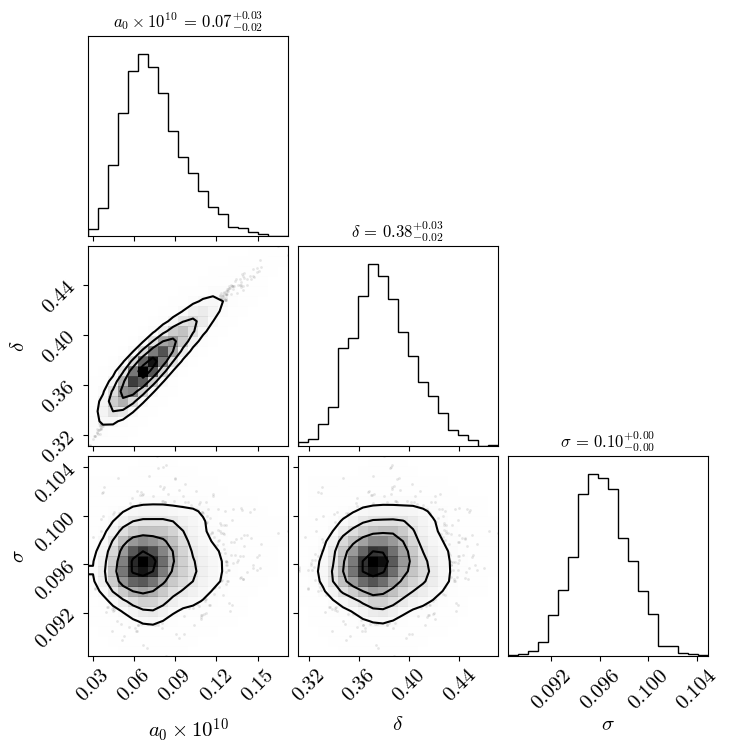

In [22]:
# g_tot_sph vs g_bar
gbar, gtot = g_bar_all, g_tot_all

Samples_NH_tot_pl        = RAR.Power_law_MCMC(gbar, gtot)
Samples_NH_tot_RAR       = RAR.RAR_func_MCMC(gbar, gtot)
Samples_NH_tot_RAR_shape = RAR.RAR_func_shape_MCMC(gbar, gtot)

A: -2.1560783
k: 0.7594991
sigma: 0.09673082


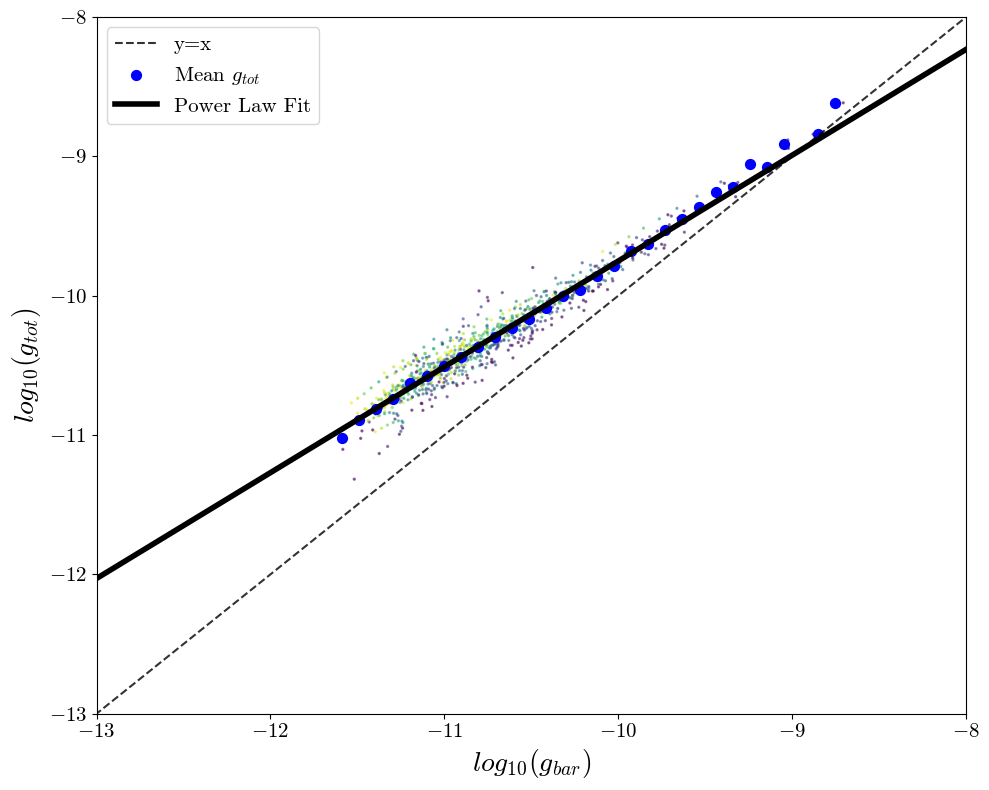

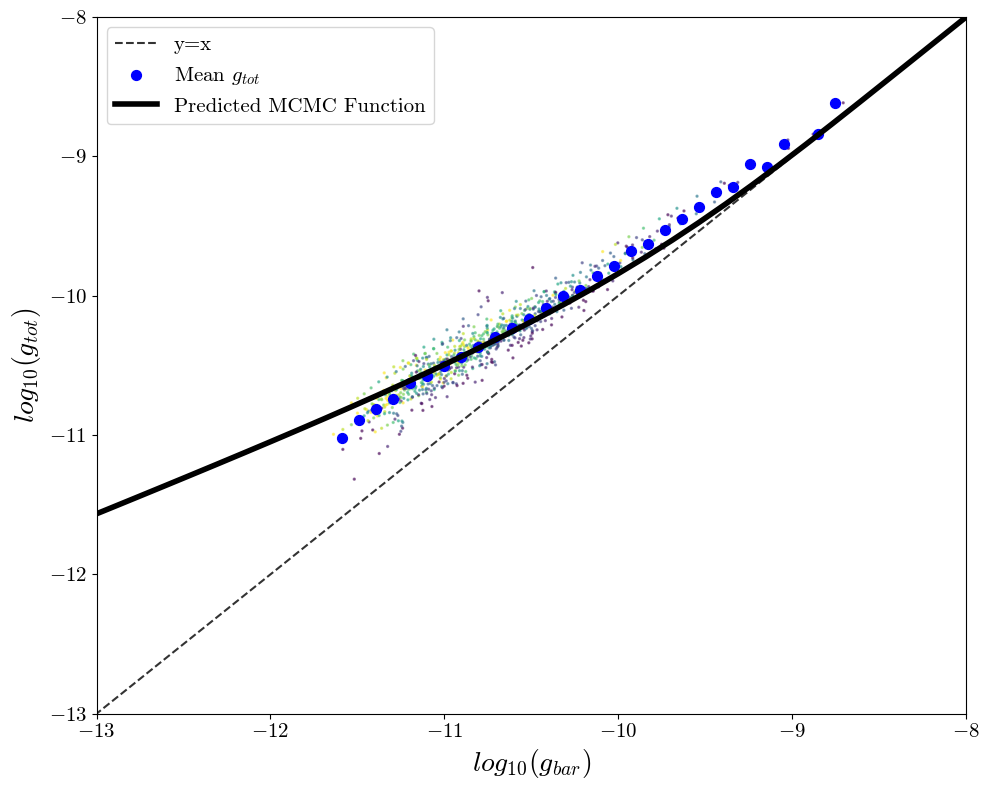

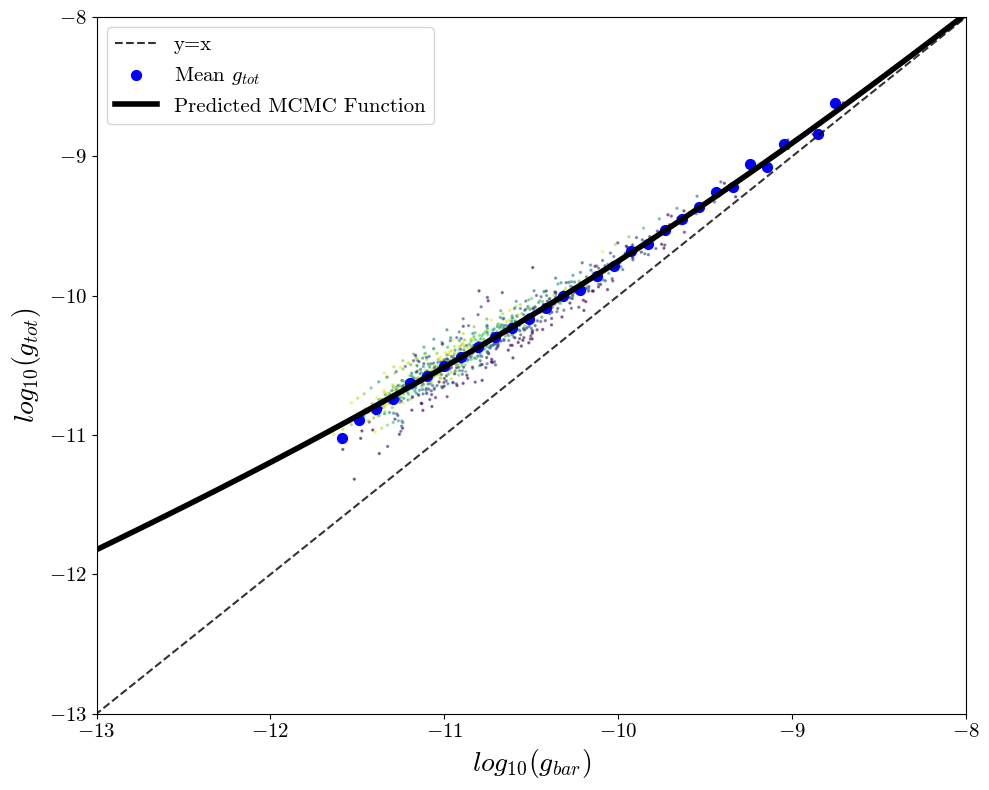

In [23]:
g_tot_RAR_pl_NH    = RAR.Plot_tot_power_law(Samples_NH_tot_pl,        rar_NH, bincenters_tot_NH, mean_tot_NH)
g_tot_RAR_RAR_NH   = RAR.Plot_tot_RAR_func( Samples_NH_tot_RAR,       rar_NH, bincenters_tot_NH, mean_tot_NH)
g_tot_RAR_shape_NH = RAR.Plot_tot_RAR_shape(Samples_NH_tot_RAR_shape, rar_NH, bincenters_tot_NH, mean_tot_NH)

# 3. Mixed RAR — $g_{obs}$ vs $g_{bar,tree}$

## TNG-50

In [24]:
Mixed_TNG, g_bar_all, g_obs_all, g_tot_all, a_r_all, a_tot_all, mean_r_all = RAR.Get_Mixed_RAR_TNG_NH(
    Chosen_galaxies_TNG, gas_r_half_TNG, gal_indices_TNG, max_radius_TNG, min_radius_TNG, sim='TNG')

g_bar_tree_plot_all = np.array(a_r_all)
g_obs_plot_all      = np.array(g_obs_all)

# Save for BIC calculation
g_bar_mix_TNG = g_bar_tree_plot_all.copy()
g_obs_mix_TNG = g_obs_plot_all.copy()

sample: 100%|██████████| 2500/2500 [00:06<00:00, 405.40it/s, 15 steps of size 9.00e-02. acc. prob=0.94]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -4.99      0.01     -4.99     -5.00     -4.98    697.24      1.00
         k      0.48      0.00      0.48      0.48      0.48   1378.89      1.00
     sigma      0.46      0.01      0.46      0.45      0.48    516.57      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


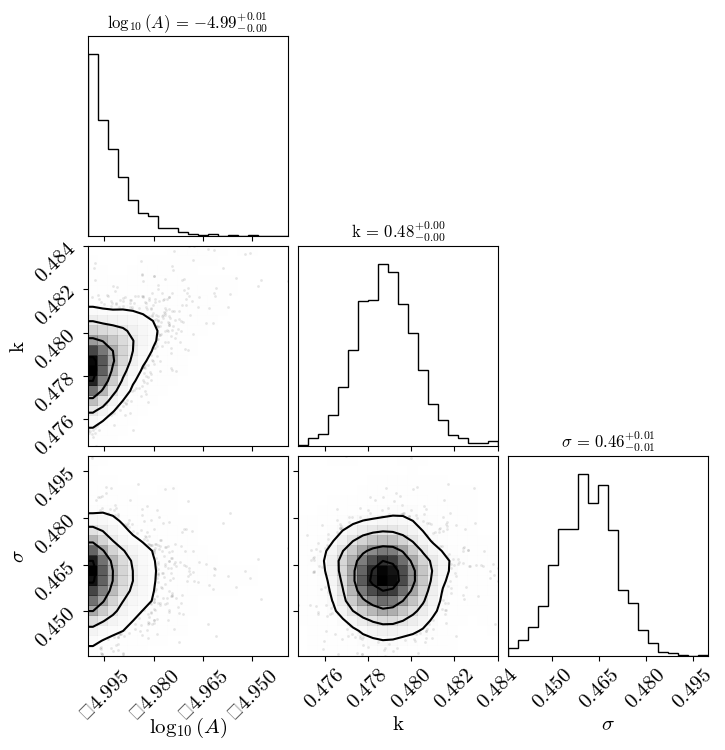

sample: 100%|██████████| 2500/2500 [00:03<00:00, 636.56it/s, 3 steps of size 9.98e-01. acc. prob=0.89] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      2.28      0.15      2.28      2.04      2.54   1947.67      1.00
     sigma      0.48      0.01      0.47      0.46      0.49   1979.24      1.00

Number of divergences: 0


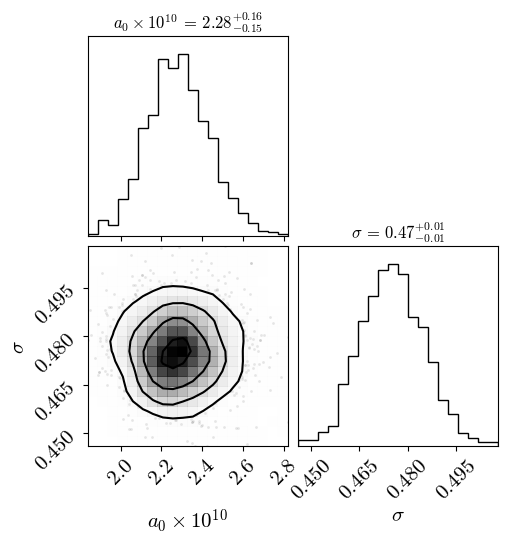

sample: 100%|██████████| 2500/2500 [06:02<00:00,  6.89it/s, 1023 steps of size 4.73e-04. acc. prob=0.82]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      2.50      0.10      2.54      2.32      2.61      3.84      1.69
     shape      1.68      0.02      1.69      1.64      1.71      5.46      1.56
     sigma      0.48      0.01      0.47      0.46      0.49      9.04      1.25

Number of divergences: 0


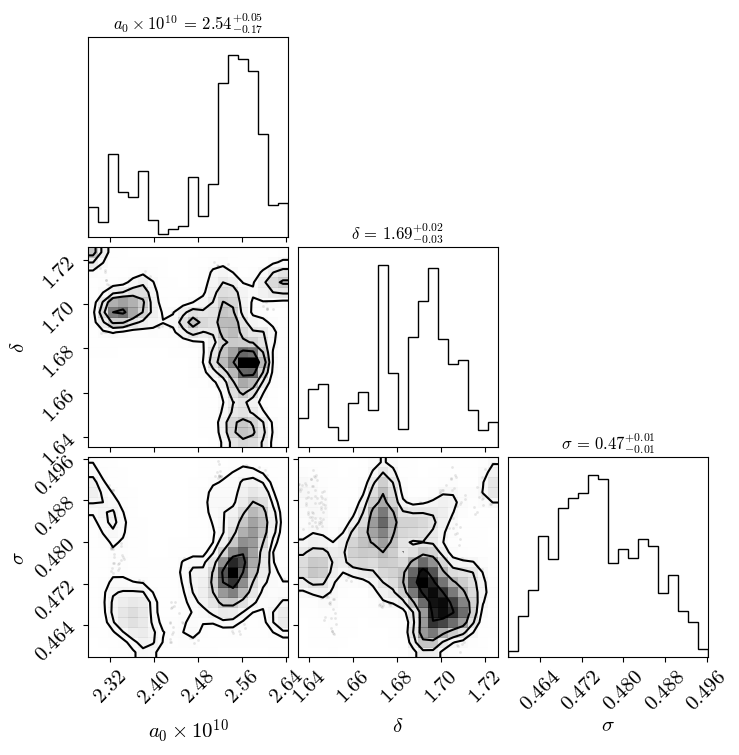

In [25]:
g_bar = np.logspace(-8, -14, 40)

# Power law
Samples_TNG_mix_pl = RAR.Power_law_MCMC(g_bar_tree_plot_all, g_obs_plot_all)
A, k = np.median(Samples_TNG_mix_pl[:, 0]), np.median(Samples_TNG_mix_pl[:, 1])
g_mixed_pl_TNG = A + k * np.log10(g_bar)

# Simple IF (delta=1)
Samples_TNG_mix_RAR = RAR.RAR_func_MCMC(g_bar_tree_plot_all, g_obs_plot_all)
a0 = np.median(Samples_TNG_mix_RAR[:, 0]); shape = 1
g_mixed_RAR_TNG = np.log10(g_bar * (1 - np.exp(-(g_bar / (a0*1e-10))**(shape/2)))**(-1/shape))

# IF with free delta
Samples_TNG_mix_shape = RAR.RAR_func_shape_MCMC(g_bar_tree_plot_all, g_obs_plot_all)
a0, shape = np.median(Samples_TNG_mix_shape[:, 0]), np.median(Samples_TNG_mix_shape[:, 1])
g_mixed_shape_TNG = np.log10(g_bar * (1 - np.exp(-(g_bar / (a0*1e-10))**(shape/2)))**(-1/shape))

/mnt/users/darnej/MPhys/Run_gals_final_funcs.py:1459: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


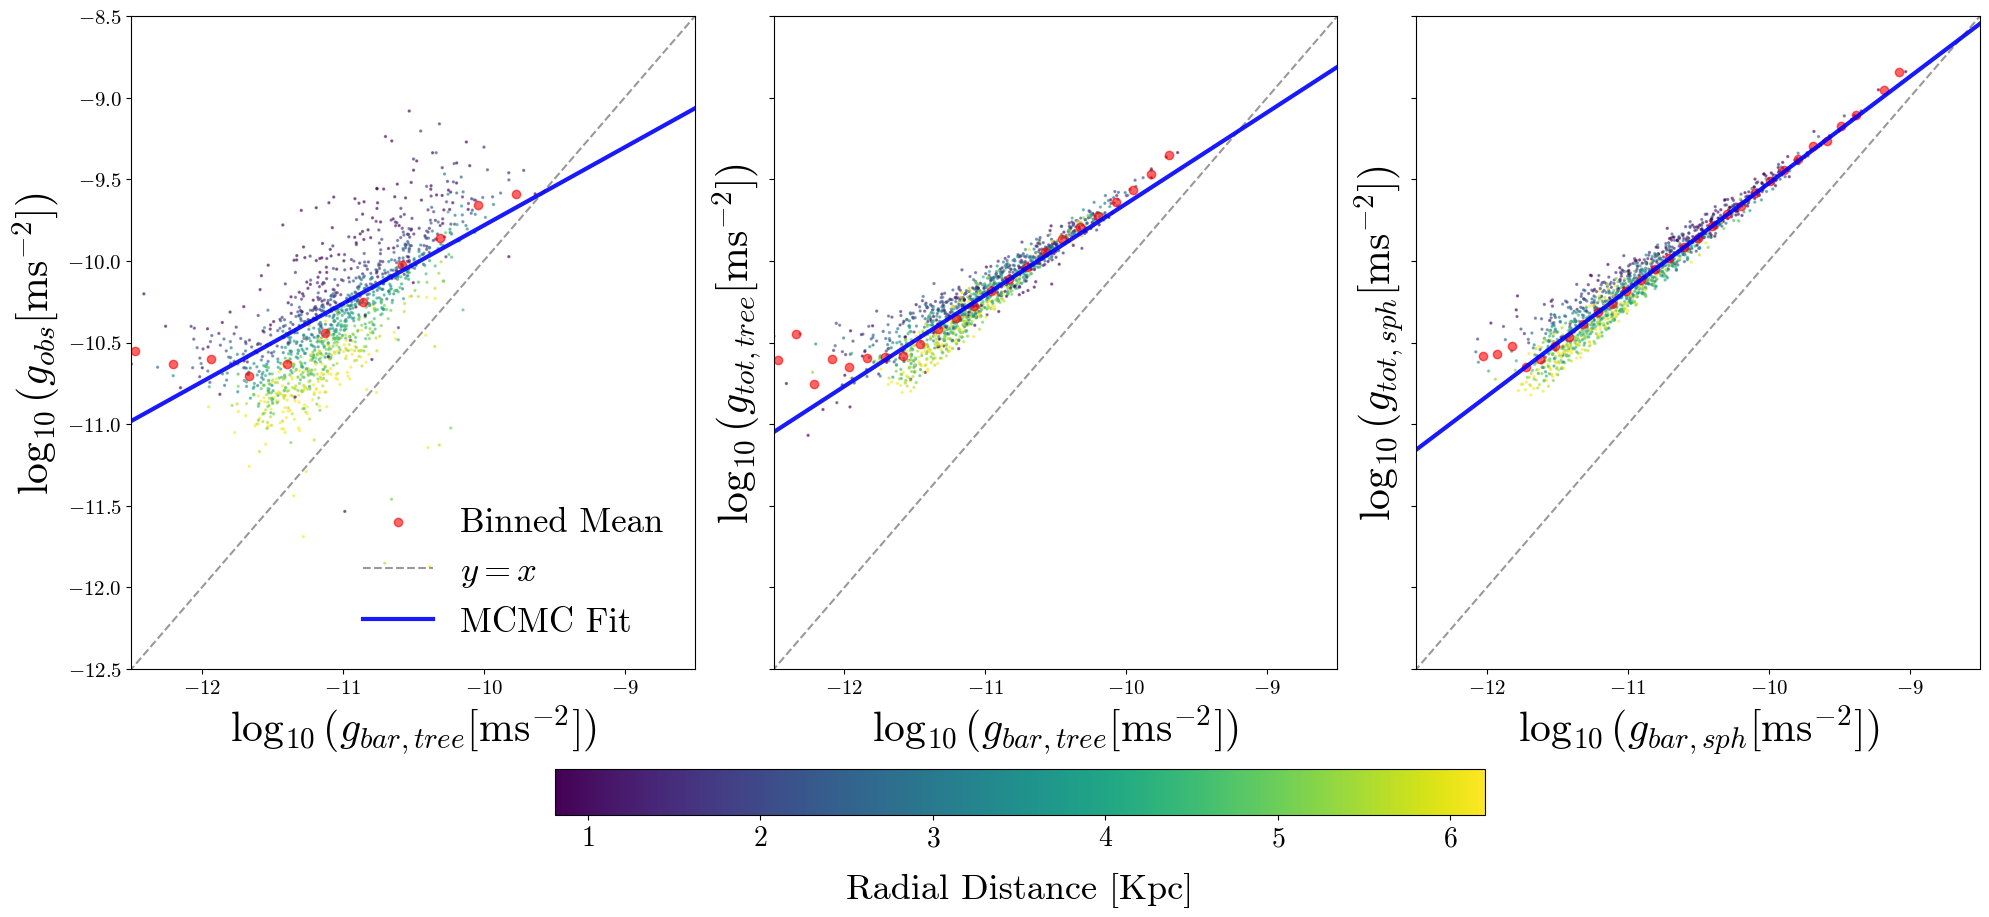

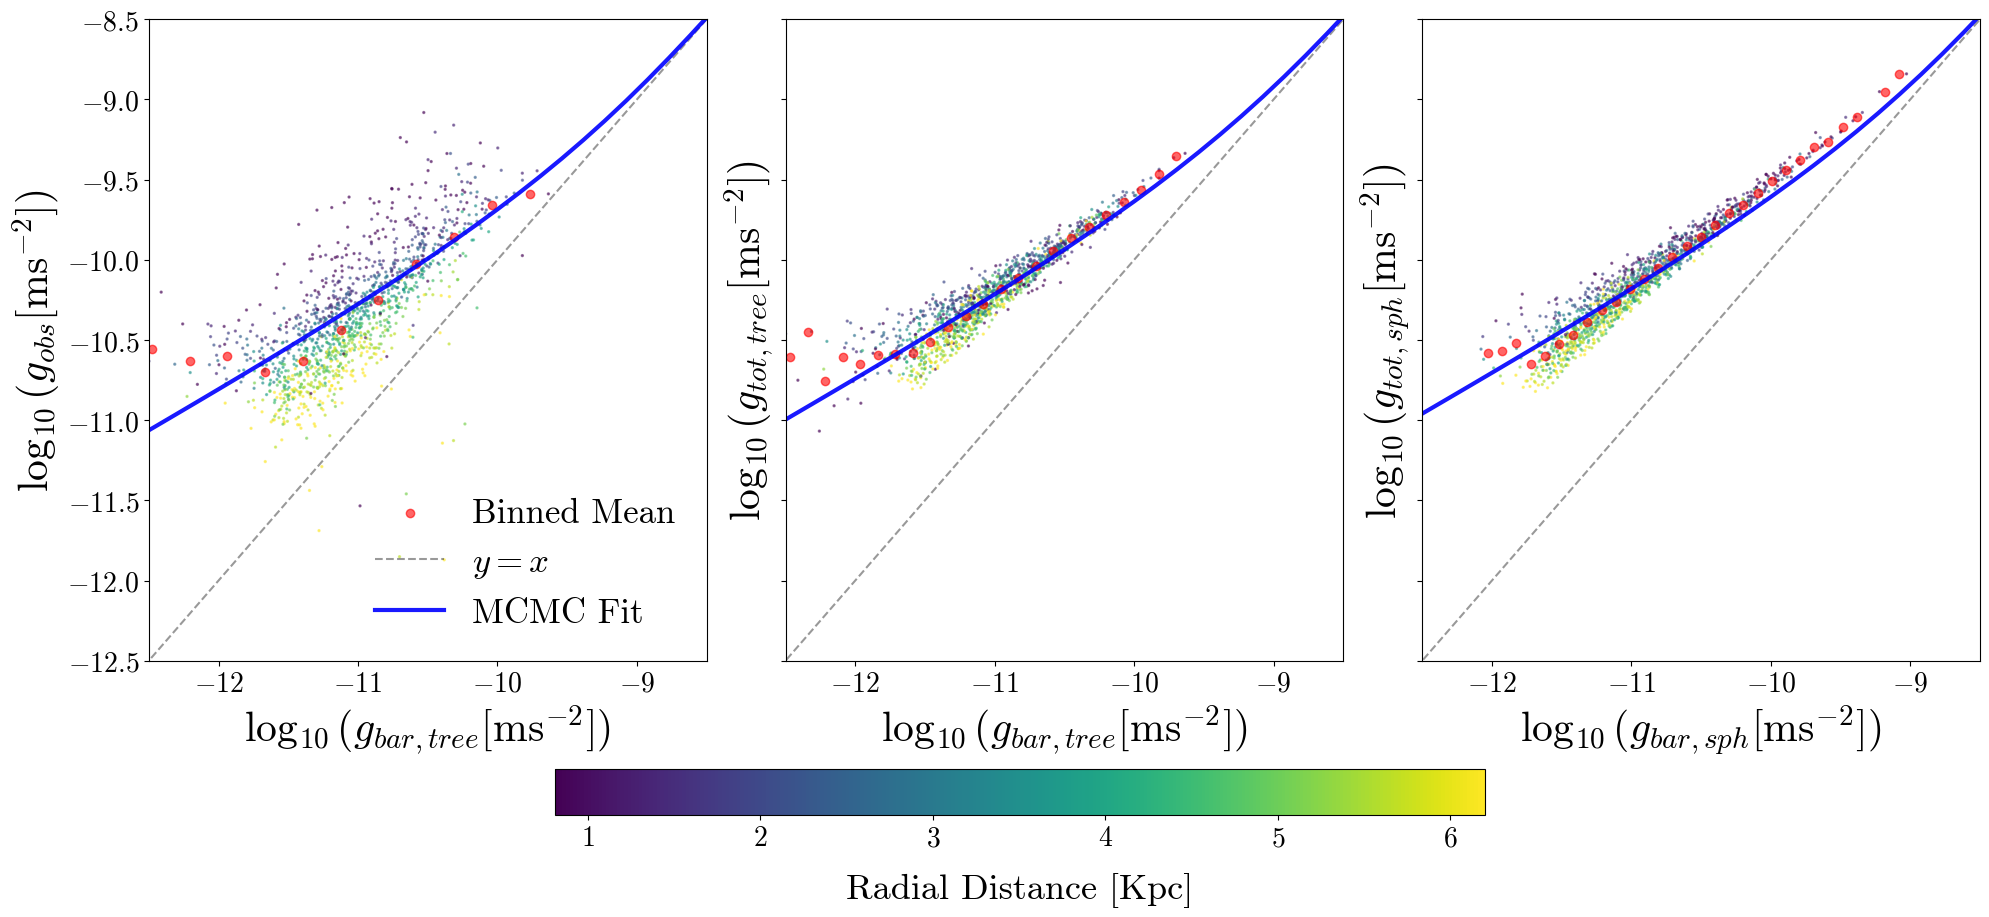

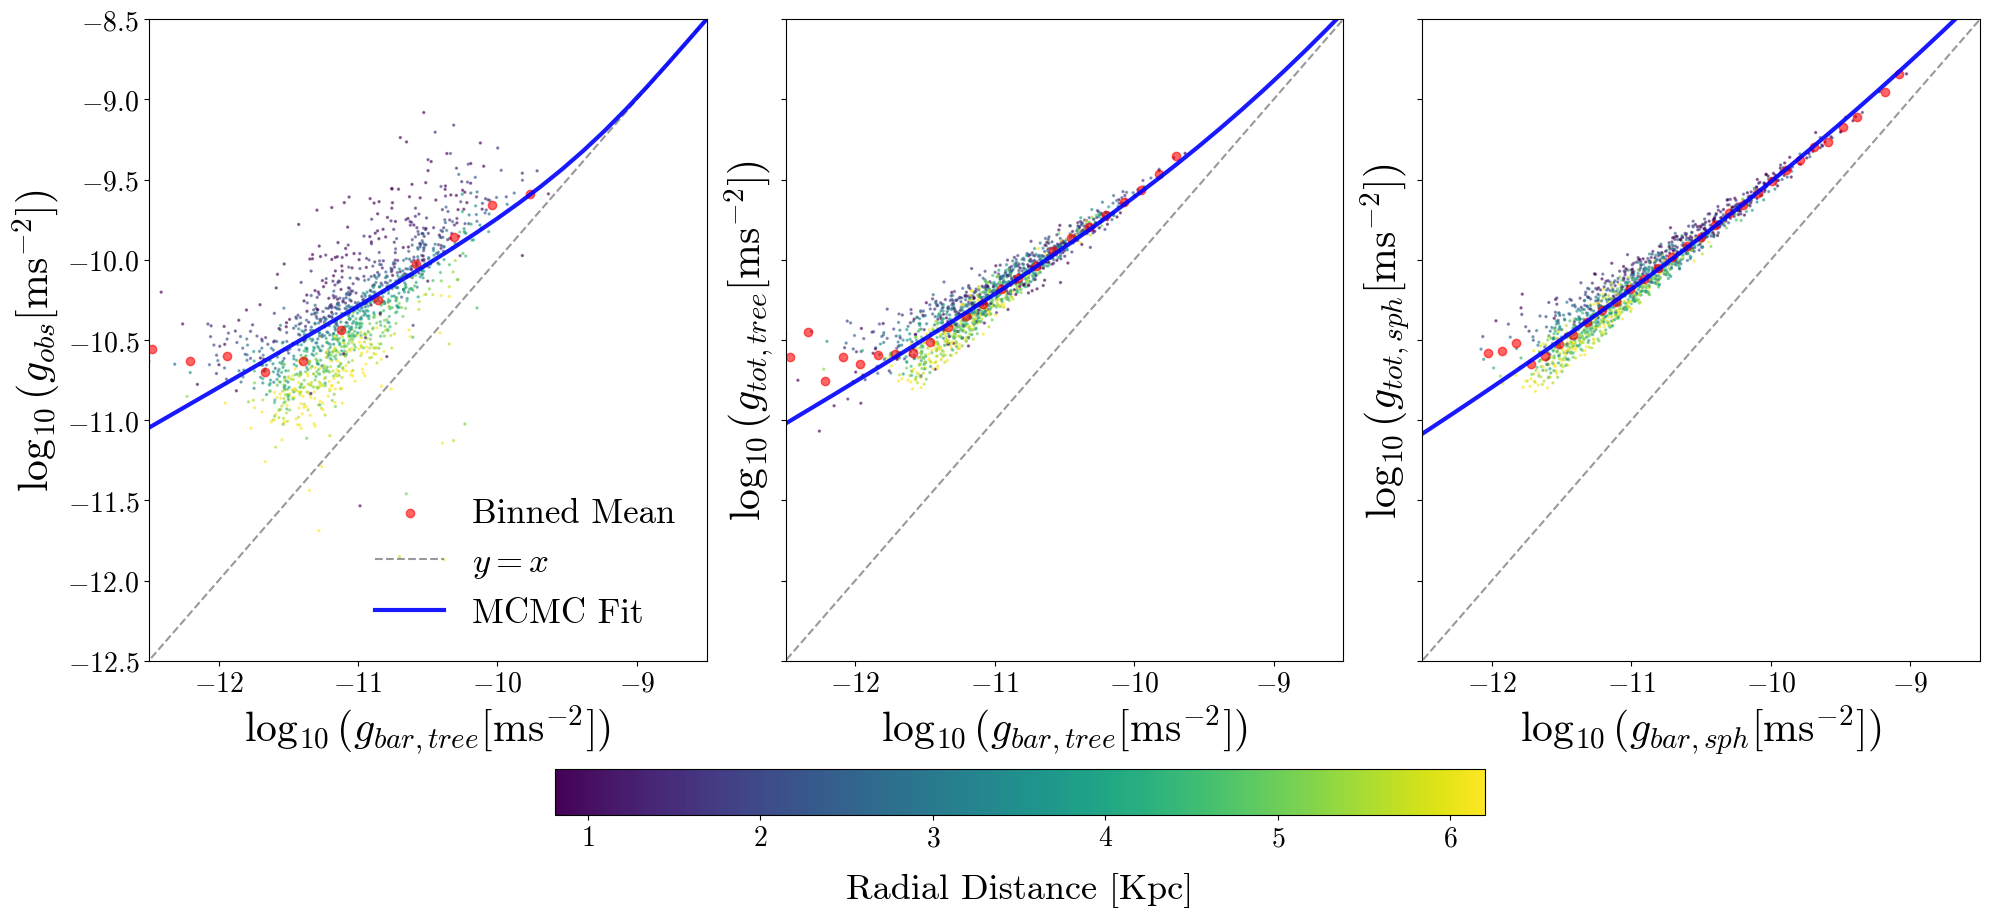

In [26]:
RAR.Plotting_mixed(Mixed_TNG, g_bar_tree_plot_all, g_obs_plot_all, bincenters_TNG_tree, mean_TNG_tree, bincenters_tot_TNG, mean_tot_TNG, rar_TNG, g_tot_pytree_pl_TNG,    g_tot_RAR_pl_TNG,    g_mixed_pl_TNG)
RAR.Plotting_mixed(Mixed_TNG, g_bar_tree_plot_all, g_obs_plot_all, bincenters_TNG_tree, mean_TNG_tree, bincenters_tot_TNG, mean_tot_TNG, rar_TNG, g_tot_pytree_RAR_TNG,   g_tot_RAR_RAR_TNG,   g_mixed_RAR_TNG)
RAR.Plotting_mixed(Mixed_TNG, g_bar_tree_plot_all, g_obs_plot_all, bincenters_TNG_tree, mean_TNG_tree, bincenters_tot_TNG, mean_tot_TNG, rar_TNG, g_tot_pytree_shape_TNG, g_tot_RAR_shape_TNG, g_mixed_shape_TNG)

## NewHorizon

In [27]:
Mixed_NH, g_bar_all, g_obs_all, g_tot_all, a_r_all, a_tot_all, mean_r_all = RAR.Get_Mixed_RAR_TNG_NH(
    Chosen_galaxies_NH, gas_r_half_NH, gal_indices_NH, max_radius_NH, min_radius_NH, sim='NH')

g_bar_tree_plot_all = np.array(a_r_all)
g_obs_plot_all      = np.array(g_obs_all)

# Save for BIC calculation
g_bar_mix_NH = g_bar_tree_plot_all.copy()
g_obs_mix_NH = g_obs_plot_all.copy()

sample: 100%|██████████| 2500/2500 [00:10<00:00, 236.17it/s, 75 steps of size 2.05e-02. acc. prob=0.95] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A     -2.13      0.09     -2.13     -2.27     -1.97    619.40      1.00
         k      0.76      0.01      0.76      0.75      0.78    619.23      1.00
     sigma      0.12      0.00      0.12      0.12      0.13    900.45      1.00

Number of divergences: 0


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


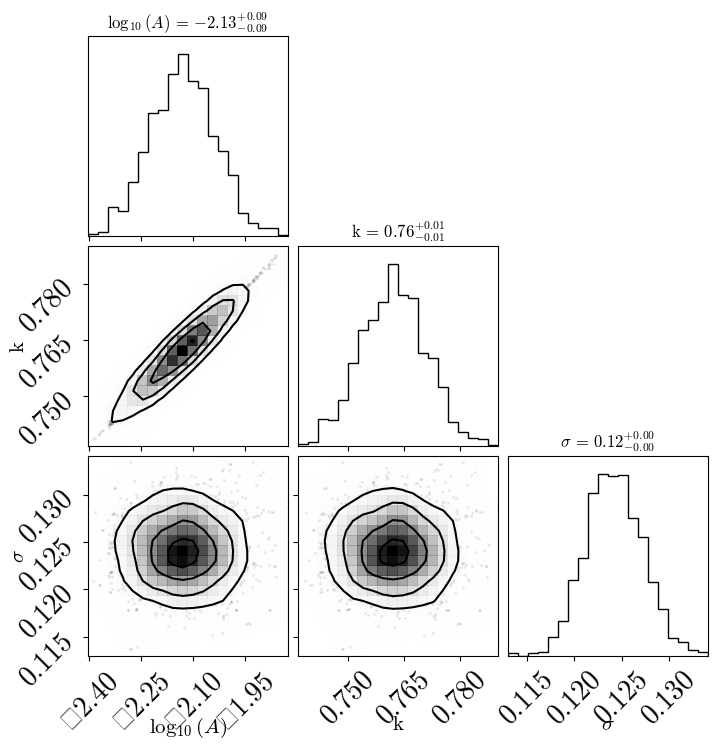

sample: 100%|██████████| 2500/2500 [00:03<00:00, 649.45it/s, 3 steps of size 8.81e-01. acc. prob=0.92] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.67      0.02      0.67      0.64      0.71   2308.37      1.00
     sigma      0.14      0.00      0.14      0.13      0.14   1471.73      1.00

Number of divergences: 0


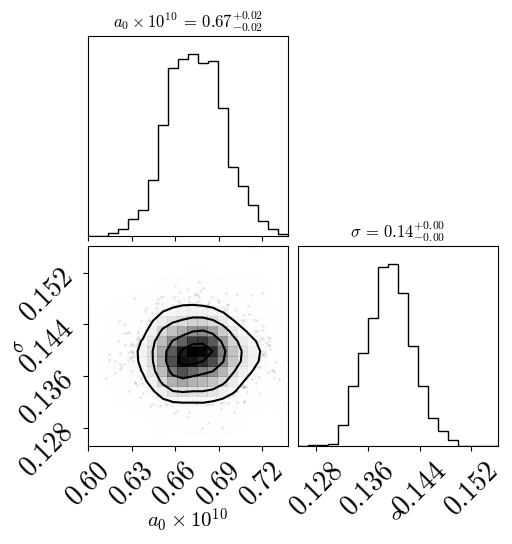

sample: 100%|██████████| 2500/2500 [00:22<00:00, 113.26it/s, 31 steps of size 6.52e-02. acc. prob=0.95] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.04      0.02      0.04      0.02      0.07    499.61      1.01
     shape      0.34      0.03      0.34      0.30      0.38    516.81      1.01
     sigma      0.13      0.00      0.13      0.12      0.13    873.05      1.00

Number of divergences: 0


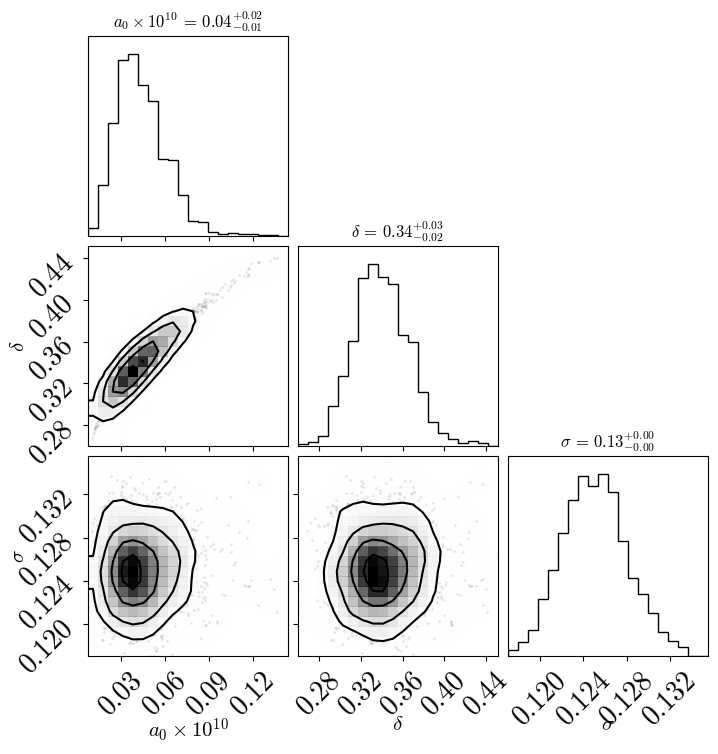

In [28]:
g_bar = np.logspace(-8, -14, 40)

# Power law
Samples_NH_mix_pl = RAR.Power_law_MCMC(g_bar_tree_plot_all, g_obs_plot_all)
A, k = np.median(Samples_NH_mix_pl[:, 0]), np.median(Samples_NH_mix_pl[:, 1])
g_mixed_pl_NH = A + k * np.log10(g_bar)

# Simple IF (delta=1)
Samples_NH_mix_RAR = RAR.RAR_func_MCMC(g_bar_tree_plot_all, g_obs_plot_all)
a0 = np.median(Samples_NH_mix_RAR[:, 0]); shape = 1
g_mixed_RAR_NH = np.log10(g_bar * (1 - np.exp(-(g_bar / (a0*1e-10))**(shape/2)))**(-1/shape))

# IF with free delta
Samples_NH_mix_shape = RAR.RAR_func_shape_MCMC(g_bar_tree_plot_all, g_obs_plot_all)
a0, shape = np.median(Samples_NH_mix_shape[:, 0]), np.median(Samples_NH_mix_shape[:, 1])
g_mixed_shape_NH = np.log10(g_bar * (1 - np.exp(-(g_bar / (a0*1e-10))**(shape/2)))**(-1/shape))

/mnt/users/darnej/MPhys/Run_gals_final_funcs.py:1459: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


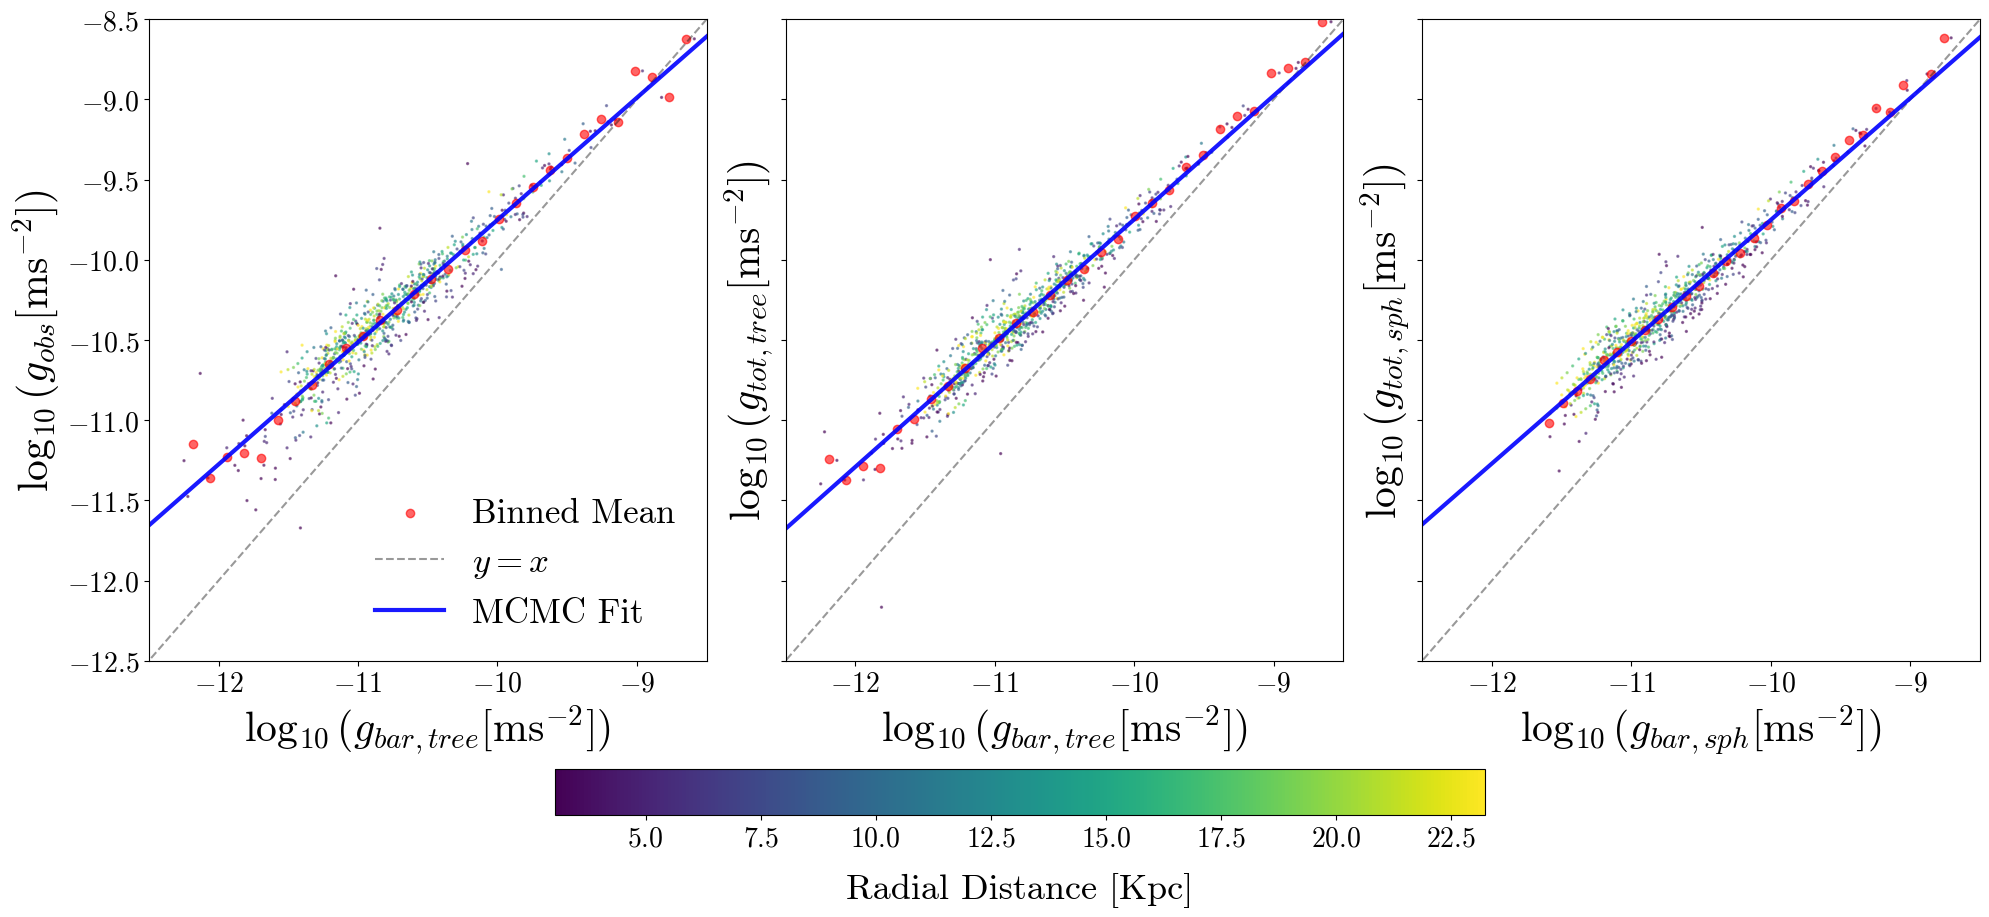

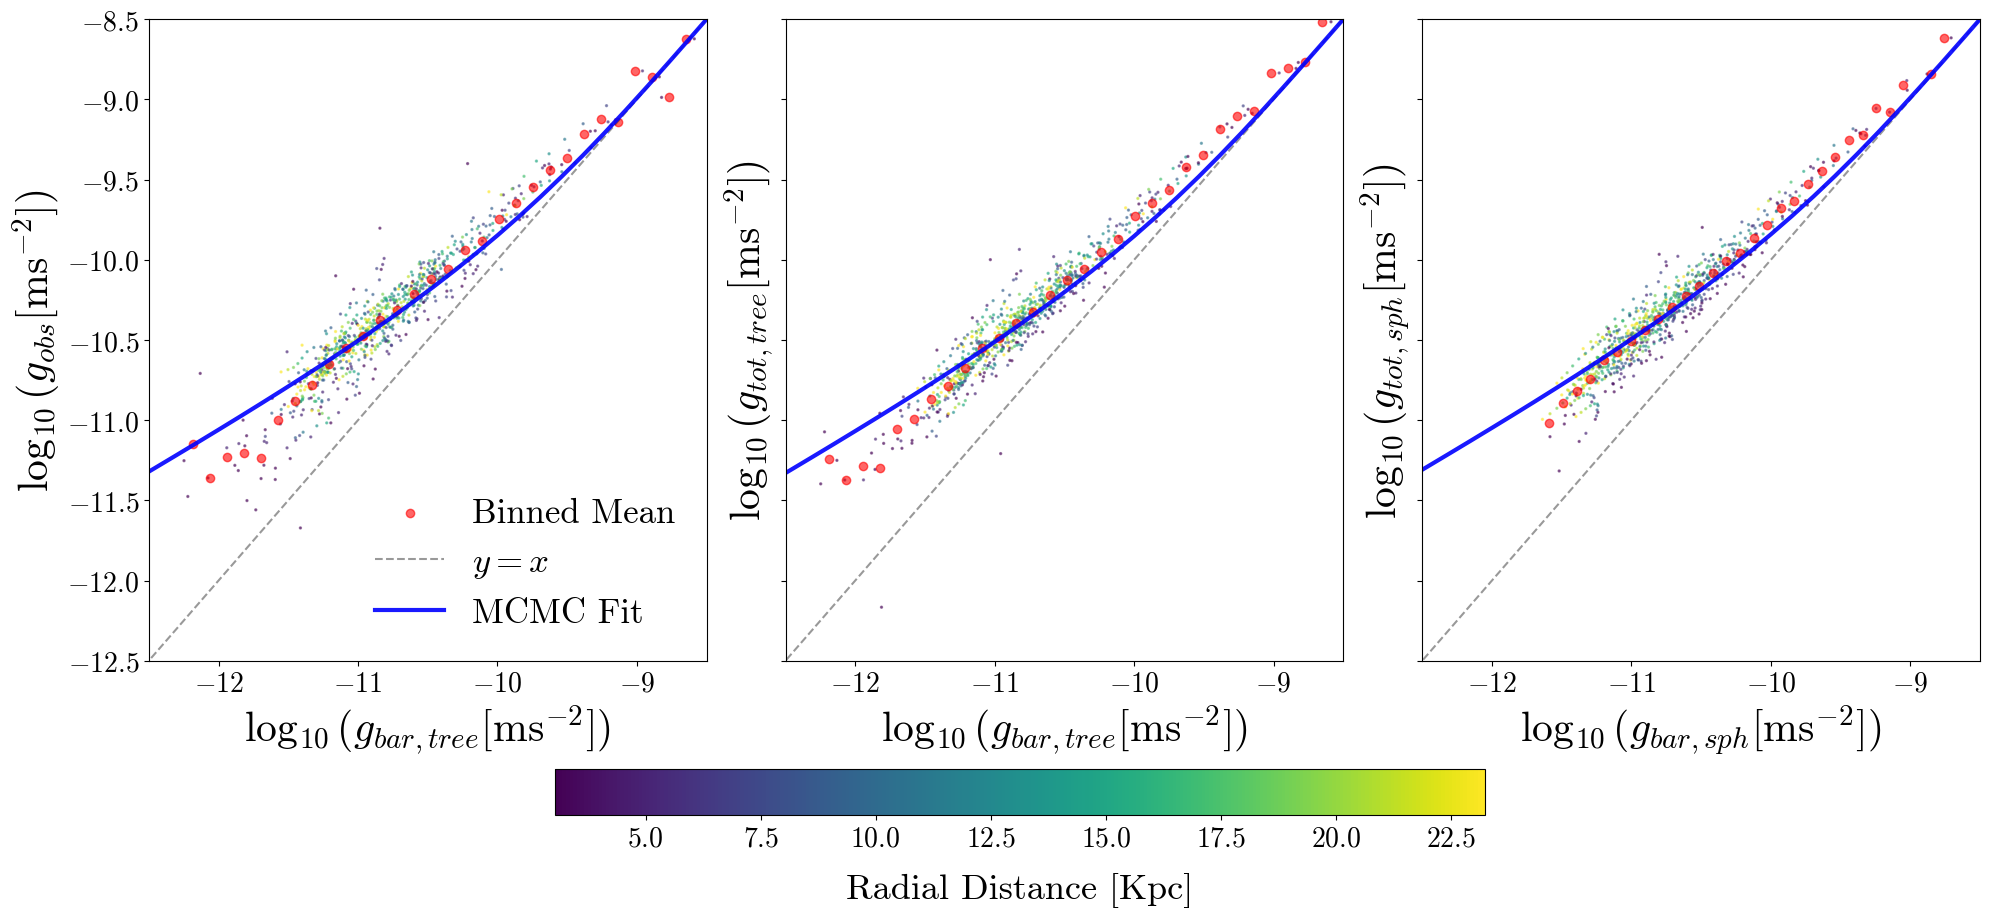

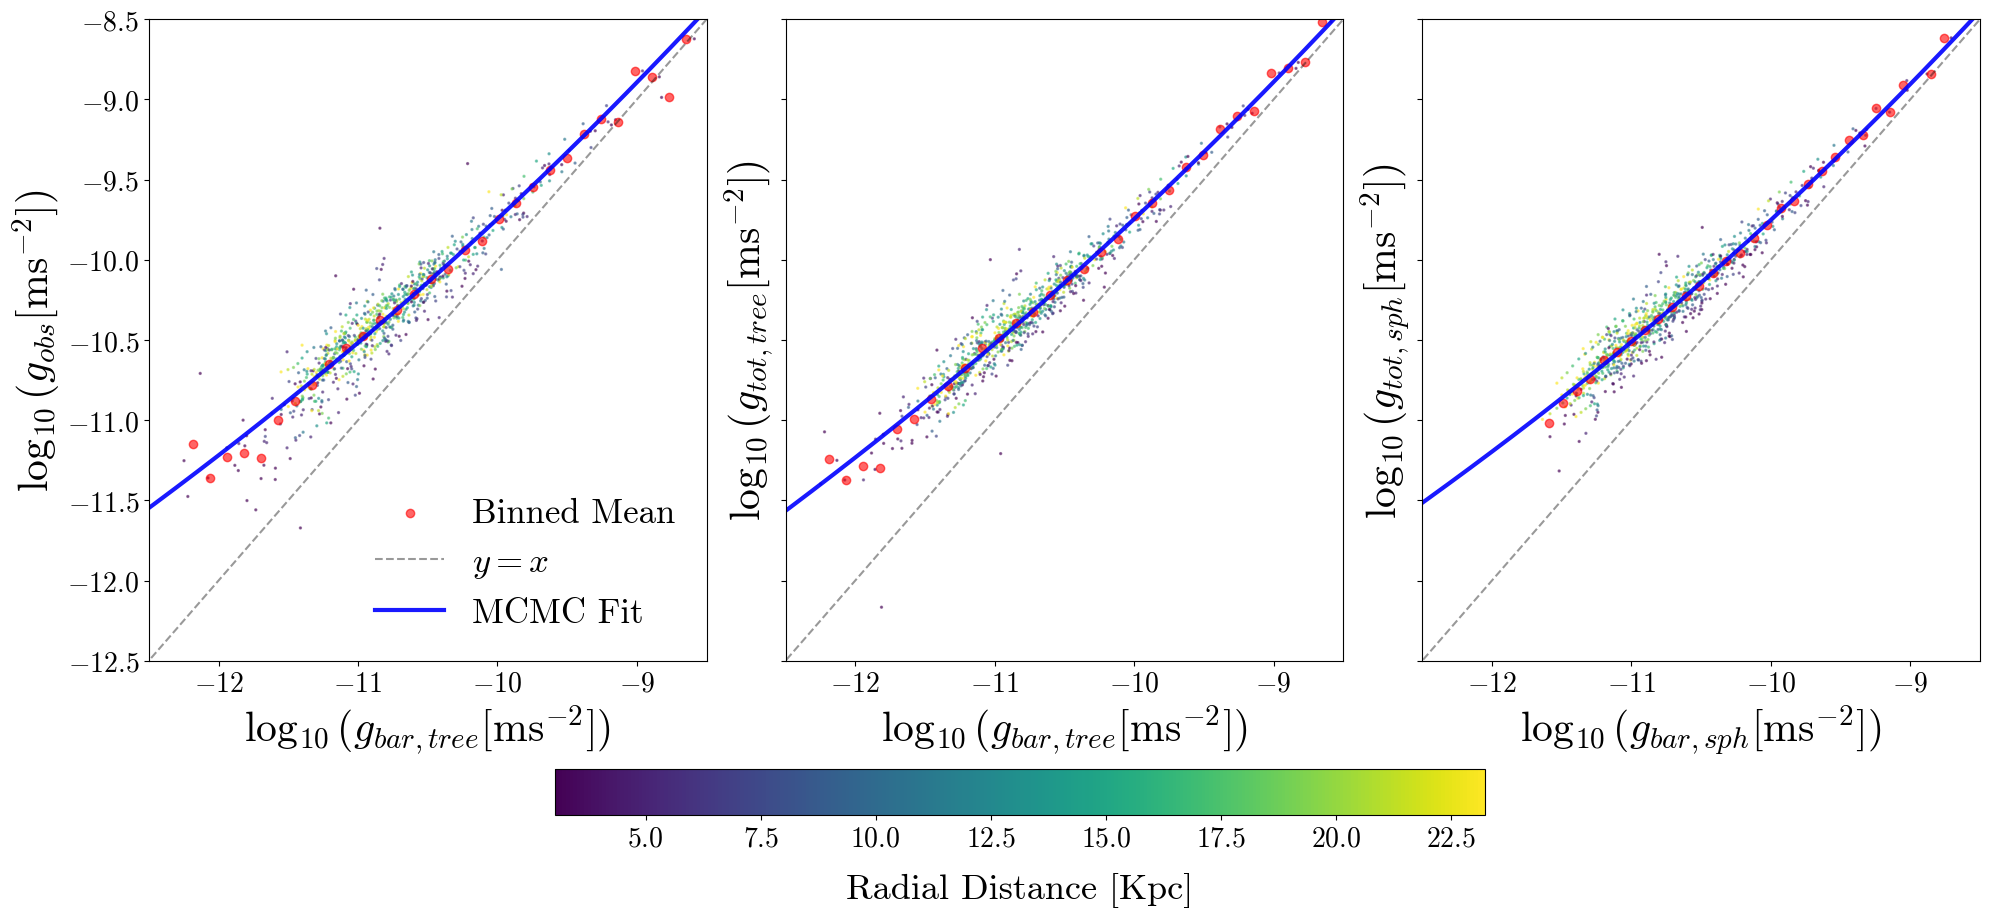

In [29]:
RAR.Plotting_mixed(Mixed_NH, g_bar_tree_plot_all, g_obs_plot_all, bincenters_NH_tree, mean_NH_tree, bincenters_tot_NH, mean_tot_NH, rar_NH, g_tot_pytree_pl_NH,    g_tot_RAR_pl_NH,    g_mixed_pl_NH)
RAR.Plotting_mixed(Mixed_NH, g_bar_tree_plot_all, g_obs_plot_all, bincenters_NH_tree, mean_NH_tree, bincenters_tot_NH, mean_tot_NH, rar_NH, g_tot_pytree_RAR_NH,   g_tot_RAR_RAR_NH,   g_mixed_RAR_NH)
RAR.Plotting_mixed(Mixed_NH, g_bar_tree_plot_all, g_obs_plot_all, bincenters_NH_tree, mean_NH_tree, bincenters_tot_NH, mean_tot_NH, rar_NH, g_tot_pytree_shape_NH, g_tot_RAR_shape_NH, g_mixed_shape_NH)

# 4. SPARC Comparison

['/mnt/users/darnej/MPhys/samples_53_scatter_EFE0_rar.npy', '/mnt/users/darnej/MPhys/labels_53_scatter_EFE0_rar.npy']


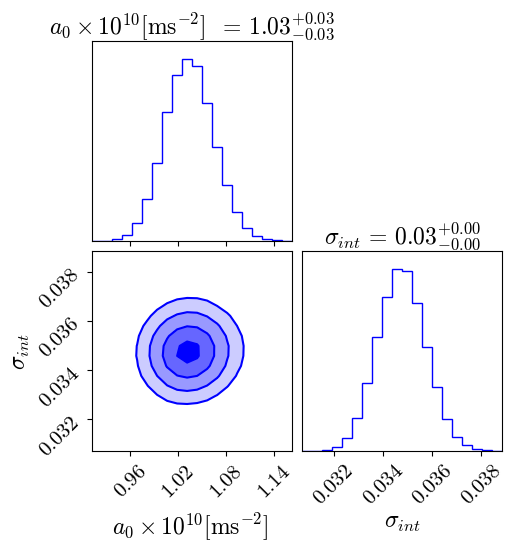

In [30]:
#OBSERVED SPARC SCATTER
import corner

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


directory = '/mnt/users/darnej/MPhys/'

files = glob.glob(os.path.join(directory, '*.npy'))

print(files)

samples = files[0]
labels = files[1]

labels = np.load(labels)

samples = np.load(samples)

a0_index = np.where(labels == 'a0')[0][0]

scatter_index = np.where(labels == 'scatter')[0][0]

a0 = samples[:, a0_index]

scatter = samples[:, scatter_index]

samples_SPARC = np.column_stack((a0, scatter))

fig = corner.corner(samples_SPARC, 
                      labels=[r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$ ', '$\sigma_{int}$'],
                      show_titles=True,
                      title_kwargs={"fontsize": 17}, 
                      label_kwargs={"fontsize": 17},
                      fill_contours=True,
                      color='blue',
                      plot_datapoints=False,
                      smooth = 1)

plt.show()


## Corner Plots — Power Law

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


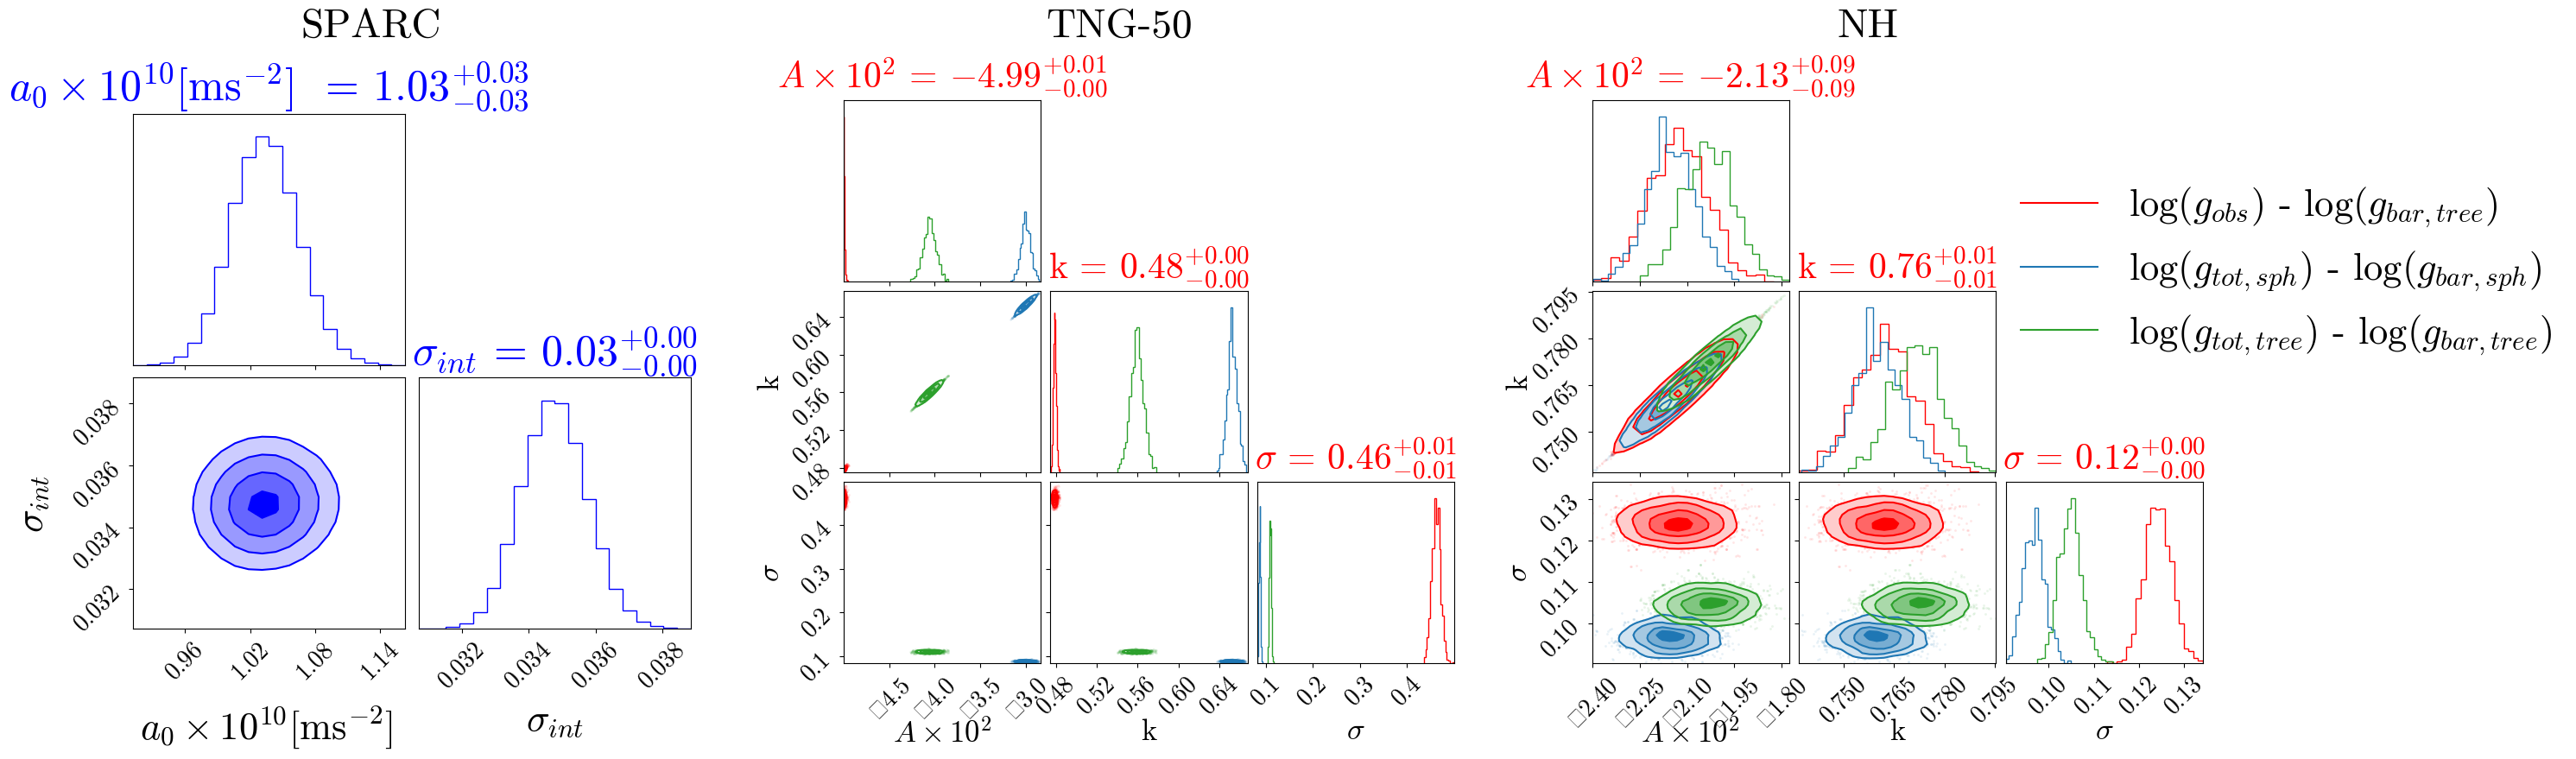

In [31]:
RAR.Plot_all_corners_pl(samples_SPARC, Samples_TNG_mix_pl, Samples_TNG_tot_pl, Samples_TNG_pytree_pl, Samples_NH_mix_pl, Samples_NH_tot_pl, Samples_NH_pytree_pl)

## Corner Plots — Simple IF

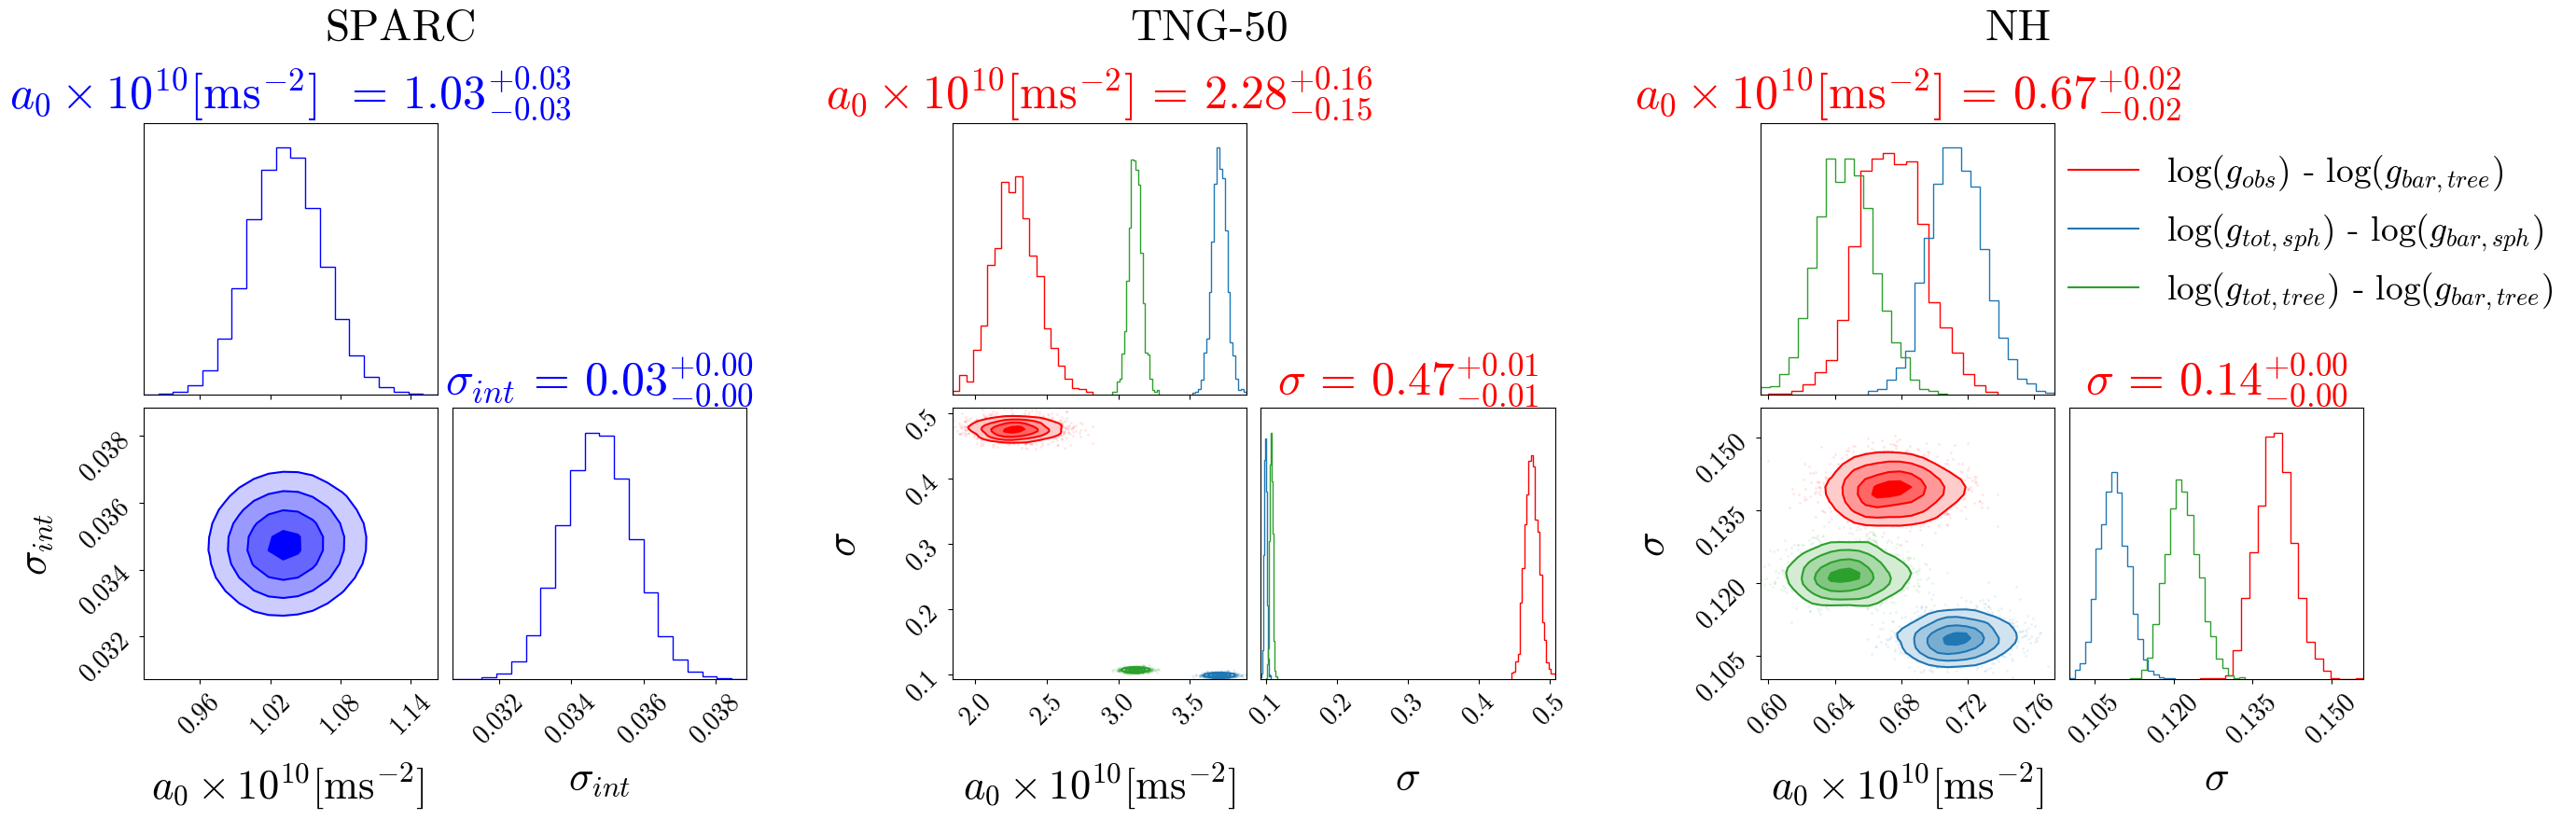

In [32]:
RAR.Plot_all_corners_RAR(samples_SPARC, Samples_TNG_mix_RAR, Samples_TNG_tot_RAR, Samples_TNG_pytree_RAR, Samples_NH_mix_RAR, Samples_NH_tot_RAR, Samples_NH_pytree_RAR)

## Corner Plots — IF with $\delta$

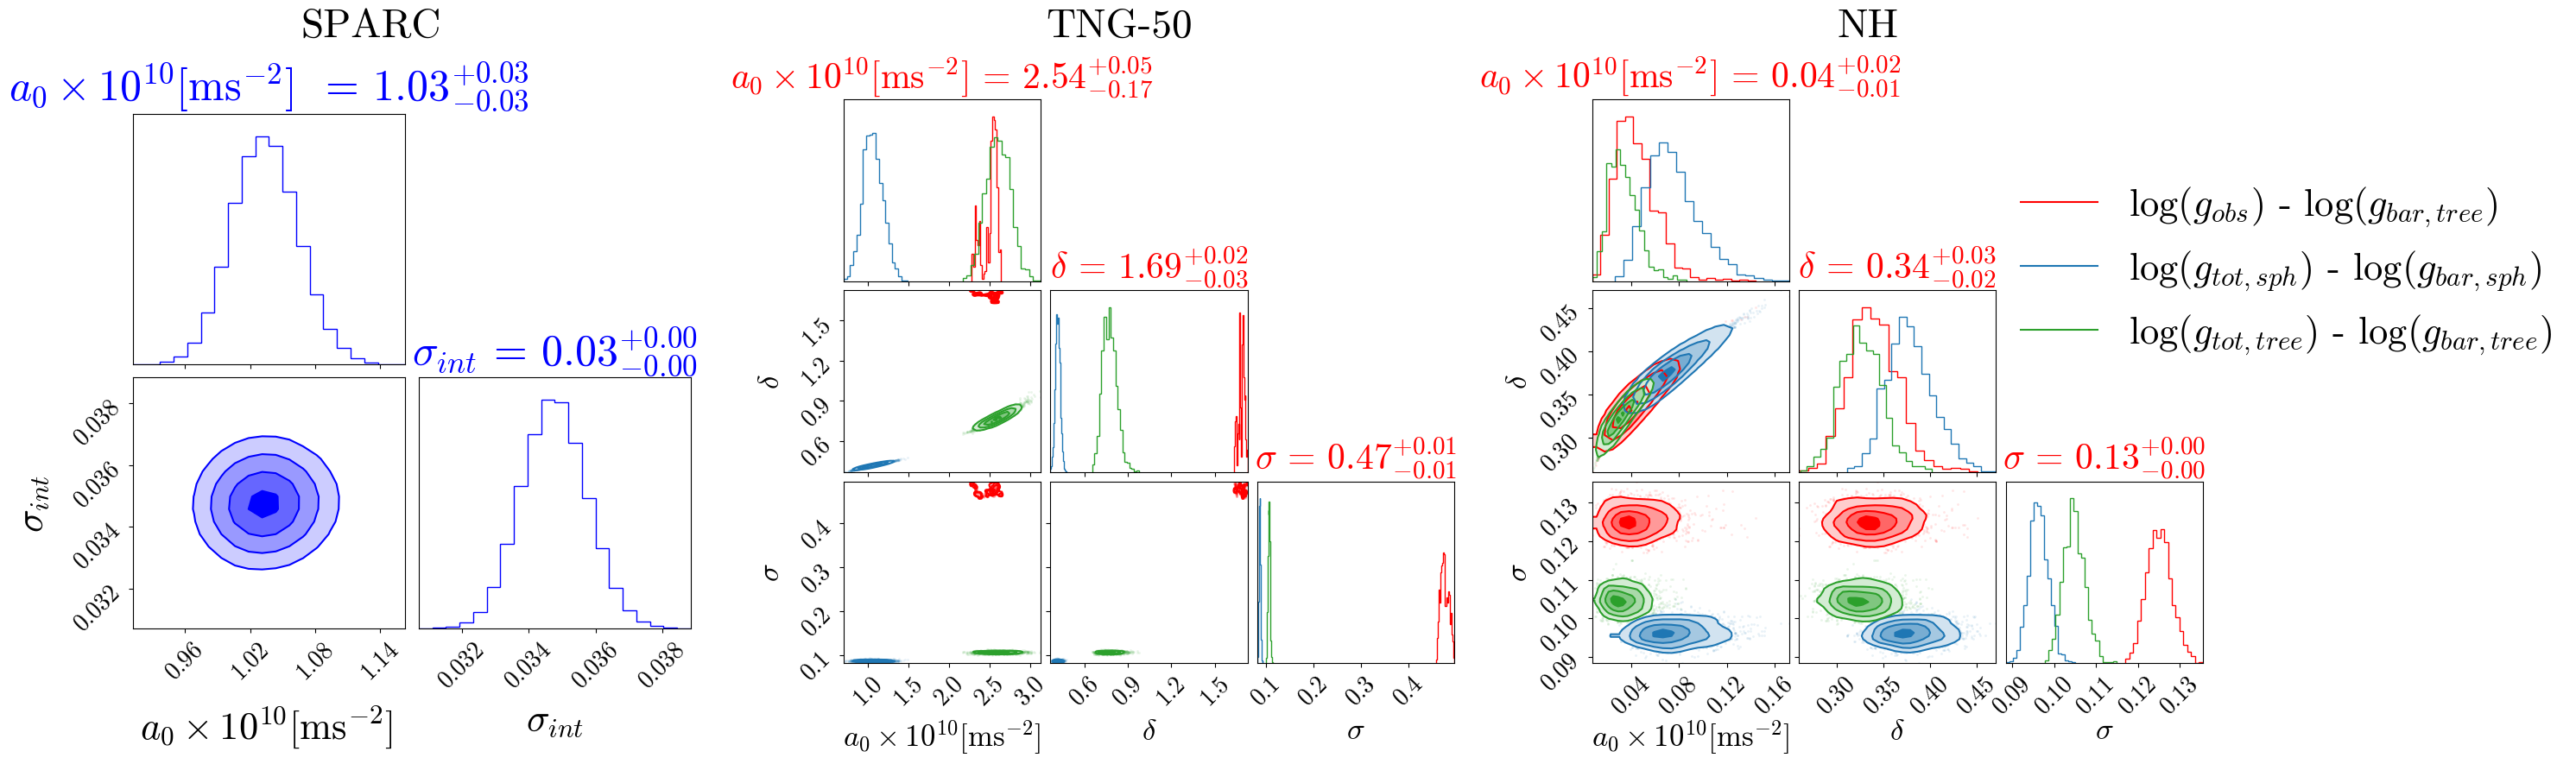

In [33]:
RAR.Plot_all_corners_shape(samples_SPARC, Samples_TNG_mix_shape, Samples_TNG_tot_RAR_shape, Samples_TNG_pytree_RAR_shape, Samples_NH_mix_shape, Samples_NH_tot_RAR_shape, Samples_NH_pytree_RAR_shape)

# 5. Mahalanobis Distances vs SPARC

In [34]:
import numpy as np
from scipy.spatial.distance import mahalanobis

mean_SPARC = np.mean(samples_SPARC, axis=0)
cov_SPARC  = np.cov(samples_SPARC, rowvar=False)

# ── TNG ──────────────────────────────────────────────────────────────────
print('=== TNG ===')
mean_obs_pl = np.mean(Samples_TNG_mix_pl, axis=0)
cov_obs_pl = np.cov(Samples_TNG_mix_pl, rowvar=False)
cov_pooled_1d = cov_obs_pl[2, 2] + cov_SPARC[1, 1]
inv_cov_pooled = [[1 / cov_pooled_1d]]
dist_1d_TNG_pl = mahalanobis(mean_obs_pl[2:], mean_SPARC[1:], inv_cov_pooled)
print('1D Mahalanobis distance TNG Power Law:', dist_1d_TNG_pl)
# Compute sample means (NOT medians)
mean_obs_RAR = np.mean(Samples_TNG_mix_RAR, axis=0)
# Compute individual covariances
cov_obs_RAR = np.cov(Samples_TNG_mix_RAR, rowvar=False)
# Pooled covariance = sum of covariances
cov_pooled = cov_obs_RAR + cov_SPARC
# Inverse of pooled covariance
inv_cov_pooled = np.linalg.pinv(cov_pooled)  # using pinv for safety
# Mahalanobis distance
distance_2d = mahalanobis(mean_obs_RAR, mean_SPARC, inv_cov_pooled)
dist_1d = mahalanobis(mean_obs_RAR[1:], mean_SPARC[1:], np.linalg.pinv(cov_pooled[1:, 1:]))
print('2D Mahalanobis distance TNG RAR func:', distance_2d)
print('1D Mahalanobis distance TNG RAR func:', dist_1d)
mean_obs_shape = np.mean(Samples_TNG_mix_shape, axis=0)
cov_obs_shape = np.cov(Samples_TNG_mix_shape, rowvar=False)
cov_pooled_1d = cov_obs_shape[2, 2] + cov_SPARC[1, 1]
inv_cov_pooled = [[1 / cov_pooled_1d]]
dist_1d_TNG_shape = mahalanobis(mean_obs_shape[2:], mean_SPARC[1:], inv_cov_pooled)
print('1D Mahalanobis distance TNG RAR shape func:', dist_1d_TNG_shape)

# ── NewHorizon ──────────────────────────────────────────────────────────────
print('=== NewHorizon ===')
mean_obs_pl = np.mean(Samples_NH_mix_pl, axis=0)
cov_obs_pl = np.cov(Samples_NH_mix_pl, rowvar=False)
cov_pooled_1d = cov_obs_pl[2, 2] + cov_SPARC[1, 1]
inv_cov_pooled = [[1 / cov_pooled_1d]]
dist_1d_NH_pl = mahalanobis(mean_obs_pl[2:], mean_SPARC[1:], inv_cov_pooled)
print('1D Mahalanobis distance NH Power Law:', dist_1d_NH_pl)
# Compute sample means (NOT medians)
mean_obs_RAR = np.mean(Samples_NH_mix_RAR, axis=0)
# Compute individual covariances
cov_obs_RAR = np.cov(Samples_NH_mix_RAR, rowvar=False)
# Pooled covariance = sum of covariances
cov_pooled = cov_obs_RAR + cov_SPARC
# Inverse of pooled covariance
inv_cov_pooled = np.linalg.pinv(cov_pooled)  # using pinv for safety
# Mahalanobis distance
distance_2d = mahalanobis(mean_obs_RAR, mean_SPARC, inv_cov_pooled)
dist_1d = mahalanobis(mean_obs_RAR[1:], mean_SPARC[1:], np.linalg.pinv(cov_pooled[1:, 1:]))
print('2D Mahalanobis distance NH RAR func:', distance_2d)
print('1D Mahalanobis distance NH RAR func:', dist_1d)
mean_obs_shape = np.mean(Samples_NH_mix_shape, axis=0)
cov_obs_shape = np.cov(Samples_NH_mix_shape, rowvar=False)
cov_pooled_1d = cov_obs_shape[2, 2] + cov_SPARC[1, 1]
inv_cov_pooled = [[1 / cov_pooled_1d]]
dist_1d_NH_shape = mahalanobis(mean_obs_shape[2:], mean_SPARC[1:], inv_cov_pooled)
print('1D Mahalanobis distance NH RAR shape func:', dist_1d_NH_shape)

=== TNG ===
1D Mahalanobis distance TNG Power Law: 46.21840567494312
2D Mahalanobis distance TNG RAR func: 45.47838839074685
1D Mahalanobis distance TNG RAR func: 44.737088317530365
1D Mahalanobis distance TNG RAR shape func: 52.37703456361956
=== NewHorizon ===
1D Mahalanobis distance NH Power Law: 28.165895935065297
2D Mahalanobis distance NH RAR func: 30.470205682958607
1D Mahalanobis distance NH RAR func: 28.697883096988516
1D Mahalanobis distance NH RAR shape func: 28.718096440193012


# 7. BIC Comparison

In [35]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ── negative log-likelihood functions ────────────────────────────────────────

def neg_log_like_power_law(params, gbar, gtot):
    A, k, sigma = params
    if sigma <= 0:
        return np.inf
    y_obs  = np.log10(gtot)
    y_pred = A + k * np.log10(gbar)
    valid  = np.isfinite(y_pred) & np.isfinite(y_obs)
    n = valid.sum()
    return n/2 * np.log(2*np.pi) + n*np.log(sigma) + np.sum((y_obs[valid] - y_pred[valid])**2) / (2*sigma**2)

def neg_log_like_IF(params, gbar, gtot):
    a0, sigma = params
    if sigma <= 0 or a0 <= 0:
        return np.inf
    shape  = 1.0
    y_obs  = np.log10(gtot)
    y_pred = np.log10(gbar * (1 - np.exp(-(gbar / (a0 * 1e-10))**(shape/2)))**(-1/shape))
    valid  = np.isfinite(y_pred) & np.isfinite(y_obs)
    n = valid.sum()
    return n/2 * np.log(2*np.pi) + n*np.log(sigma) + np.sum((y_obs[valid] - y_pred[valid])**2) / (2*sigma**2)

def neg_log_like_IF_delta(params, gbar, gtot):
    a0, shape, sigma = params
    if sigma <= 0 or a0 <= 0 or shape <= 0:
        return np.inf
    y_obs  = np.log10(gtot)
    y_pred = np.log10(gbar * (1 - np.exp(-(gbar / (a0 * 1e-10))**(shape/2)))**(-1/shape))
    valid  = np.isfinite(y_pred) & np.isfinite(y_obs)
    n = valid.sum()
    return n/2 * np.log(2*np.pi) + n*np.log(sigma) + np.sum((y_obs[valid] - y_pred[valid])**2) / (2*sigma**2)


# ── multi-start gradient optimisation to find MLE ────────────────────────────

def find_mle(neg_log_like_fn, bounds, gbar, gtot, n_starts=5, seed=42):
    """
    Run L-BFGS-B from n_starts random points in parameter space.
    Returns (best_params, max_log_likelihood).
    """
    rng = np.random.default_rng(seed)
    lo  = np.array([b[0] for b in bounds])
    hi  = np.array([b[1] for b in bounds])

    best_nll    = np.inf
    best_params = None

    for _ in range(n_starts):
        x0  = rng.uniform(lo, hi)
        res = minimize(
            neg_log_like_fn, x0, args=(gbar, gtot),
            method='L-BFGS-B', bounds=bounds,
            options={'maxiter': 10000, 'ftol': 1e-12, 'gtol': 1e-8}
        )

        print(res.fun)
        if res.fun < best_nll:
            best_nll    = res.fun
            best_params = res.x

    return best_params, -best_nll   # return maximum log-likelihood


# ── BIC from MLE ──────────────────────────────────────────────────────────────

def compute_bic_mle(gbar, gtot, neg_log_like_fn, bounds, k_params, n_starts=5):
    valid = np.isfinite(np.log10(gbar)) & np.isfinite(np.log10(gtot)) & (gbar > 0) & (gtot > 0)
    gbar_v, gtot_v = gbar[valid], gtot[valid]
    n = valid.sum()
    _, max_log_L = find_mle(neg_log_like_fn, bounds, gbar_v, gtot_v, n_starts=n_starts)
    return k_params * np.log(n) - 2 * max_log_L


# ── model registry ────────────────────────────────────────────────────────────
#   (label,       neg-ll function,          bounds,                           k)
MODELS = [
    ('Power Law', neg_log_like_power_law, [(-5, 5), (-5, 5), (1e-6, 5)],       3),
    ('IF',        neg_log_like_IF,        [(1e-4, 5), (1e-6, 5)],              2),
    ('IF+delta',  neg_log_like_IF_delta,  [(1e-4, 5), (0.1, 3), (1e-6, 5)],   3),
]


# ── data reconstruction helpers ───────────────────────────────────────────────

def get_pytree_data(pytree_results, gas_r_half, gal_indices, min_radius, max_radius):
    g_bar_list, g_tot_list = [], []
    for gal in pytree_results:
        g_tot  = pytree_results[gal][1]
        g_bar  = pytree_results[gal][0]
        mean_r = pytree_results[gal][2]
        r_half = gas_r_half[gal == gal_indices][0]
        r_over_r_half = mean_r / r_half
        r_mask = (r_over_r_half <= max_radius) & (r_over_r_half >= min_radius)
        g_tot, g_bar = g_tot[r_mask], g_bar[r_mask]
        mask = (g_bar > 1e-14) & (g_tot > 1e-14)
        g_bar_list.extend(g_bar[mask])
        g_tot_list.extend(g_tot[mask])
    gbar = np.array(g_bar_list)
    gtot = np.array(g_tot_list)
    valid = (gbar > 0) & (gtot > 0)
    return gbar[valid], gtot[valid]

def get_rar_sph_data(rar):
    g_bar_list, g_obs_list = [], []
    for gal in rar:
        g_bar = rar[gal][0]
        g_obs = rar[gal][4]
        mask  = (g_bar > 0) & (g_obs > 0)
        g_bar_list.extend(g_bar[mask])
        g_obs_list.extend(g_obs[mask])
    return np.array(g_bar_list), np.array(g_obs_list)


# ── reconstruct datasets ──────────────────────────────────────────────────────

gbar_pytree_TNG, gtot_pytree_TNG = get_pytree_data(
    pytree_results_TNG, gas_r_half_TNG, gal_indices_TNG, min_radius_TNG, max_radius_TNG)
gbar_pytree_NH, gtot_pytree_NH = get_pytree_data(
    pytree_results_NH,  gas_r_half_NH,  gal_indices_NH,  min_radius_NH,  max_radius_NH)

gbar_sph_TNG, gobs_sph_TNG = get_rar_sph_data(rar_TNG)
gbar_sph_NH,  gobs_sph_NH  = get_rar_sph_data(rar_NH)


# ── compute all BICs ──────────────────────────────────────────────────────────

rar_configs = [
    ('TNG', 'Pytree',  gbar_pytree_TNG, gtot_pytree_TNG),
    ('NH',  'Pytree',  gbar_pytree_NH,  gtot_pytree_NH),
    ('TNG', 'RAR_sph', gbar_sph_TNG,   gobs_sph_TNG),
    ('NH',  'RAR_sph', gbar_sph_NH,    gobs_sph_NH),
    ('TNG', 'Mixed',   g_bar_mix_TNG,  g_obs_mix_TNG),
    ('NH',  'Mixed',   g_bar_mix_NH,   g_obs_mix_NH),
]

rows = []
for sim, rar_type, gbar, gobs in rar_configs:
    for model_label, neg_ll_fn, bounds, k_params in MODELS:
        bic_val = compute_bic_mle(gbar, gobs, neg_ll_fn, bounds, k_params, n_starts=5)
        rows.append({'Simulation': sim, 'RAR Type': rar_type, 'Model': model_label, 'BIC': round(bic_val, 1)})
        print(f'{sim:3s}  {rar_type:8s}  {model_label:10s}  BIC = {bic_val:.1f}')

bic_df    = pd.DataFrame(rows)
bic_table = bic_df.pivot_table(index=['Simulation', 'RAR Type'], columns='Model', values='BIC')
bic_table = bic_table[['Power Law', 'IF', 'IF+delta']]
bic_table.columns.name = None

print()
print(bic_table.to_string())
bic_table

-1047.4282719799157
-1047.4282719531434
-1047.4282720434758
-1047.4282719476366
-1047.4282719544442
TNG  Pytree    Power Law   BIC = -2073.3
-1076.1906796997437
-1076.1906796997428
-1076.1906796997405
-1076.190679699741
-1076.1906796997418
TNG  Pytree    IF          BIC = -2138.0
-1084.625824560638
-1084.6258245606477
-1084.6258245606423
-1084.6258245606289
-1069.9367893764593
TNG  Pytree    IF+delta    BIC = -2147.7
-686.2917300605625
-686.2917300606925
-686.2917300597903
-686.2917300603917
-686.2917300818241
NH   Pytree    Power Law   BIC = -1352.5
-562.8222012917403
-562.8222012917402
-562.8222012917406
-562.8222012917411
-562.8222012917404
NH   Pytree    IF          BIC = -1112.2
-686.1477497677693
-686.1477497678836
-686.1477497692349
-656.164679319593
-686.147749767975
NH   Pytree    IF+delta    BIC = -1352.2
-405.2496024131133
-405.249602409742
-405.24960240961343
-405.24960241181736
-405.24960241140514
TNG  RAR_sph   Power Law   BIC = -789.0
-367.50802639349615
-367.50802639349

Power Law      IF  IF+delta
Simulation RAR Type                             
NH         Mixed       -1084.1  -901.0   -1070.3
           Pytree      -1352.5 -1112.2   -1352.2
           RAR_sph      -515.0  -466.3    -520.9
TNG        Mixed        1669.4  1737.4    1730.4
           Pytree      -2073.3 -2138.0   -2147.7
           RAR_sph      -789.0  -720.7    -799.6